# Deduplicating 50,000 historical figures with cpplink

This notebook takes one real, messy dataset through the whole `cpplink` pipeline from Python: fetching and preparing the data, drafting a schema, profiling the columns before any model exists, pricing the blocking, fitting the fuzzy thresholds, learning the Fellegi-Sunter model, scoring the candidate pairs, explaining one score, joining the predictions into clusters, and checking the answer against the ground truth the pipeline never saw.

The data is `historical_50k` from [splink_datasets](https://github.com/moj-analytical-services/splink_datasets): 50,578 records describing 5,156 historical people scraped from Wikidata, with duplicates that carry nicknames, typos, missing fields and shifted dates.
It is the main small benchmark of the project, so every number below can be compared with the ones in `bench/`.

Everything is computed by the `cpplink` core.
The Python package is the same binary loaded into the interpreter, and `Linker` loads the parquet input once and runs every stage against the same store, so nothing here re-implements a bit of the model.
What the notebook adds is plots and tables.

**Requirements**: the `cpplink` package built in the project's conda environment (`pip install -e .` from the repository root), plus `pandas` and `matplotlib`.
The dataset is 1.6 MB and is downloaded once into `work/`.

In [1]:
import io
import itertools
import json
import time
import urllib.request
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import cpplink

print("cpplink", cpplink.__version__)
WORK = Path("work")
WORK.mkdir(exist_ok=True)
timings = {}

cpplink 0.1.0


A little presentation code, kept in one place: a small fixed palette, thin marks, hairline grid, and a helper that turns a list of bound report objects into a `DataFrame` through `cpplink.to_dict`.

In [2]:
%config InlineBackend.figure_format = "retina"

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#e34948"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUES = mpl.colors.LinearSegmentedColormap.from_list("blues", ["#f4f7fc", "#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIVERGING = mpl.colors.LinearSegmentedColormap.from_list("bluered", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#7a1414"])

mpl.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (9, 4), "figure.facecolor": "white",
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.solid_capstyle": "round",
})


def frame(objects, columns=None):
    "A DataFrame over bound report objects, one row per object."
    rows = [cpplink.to_dict(o) for o in objects]
    df = pd.DataFrame(rows)
    return df[columns] if columns else df


def fmt(df, **formats):
    "A Styler with thousands separators on integers and the given per-column formats."
    ints = {c: "{:,}" for c in df.select_dtypes("integer").columns}
    return df.style.format({**ints, **formats}).hide(axis="index")


def hbars(ax, labels, values, color=BLUE, height=0.55):
    "Thin horizontal bars, largest at the top."
    y = np.arange(len(labels))[::-1]
    ax.barh(y, values, height=height, color=color)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    return y

## 1. The data

`historical_50k` ships as one parquet file with a `cluster` column naming the true person behind each record.
Fetch it, look at one person, and then take the label out before the pipeline sees the file.

In [3]:
URL = ("https://raw.githubusercontent.com/moj-analytical-services/splink_datasets"
       "/master/data/historical_figures_with_errors_50k.parquet")
raw_path = WORK / "historical_50k.raw.parquet"
if not raw_path.exists():
    raw_path.write_bytes(urllib.request.urlopen(URL, timeout=120).read())
raw = pd.read_parquet(raw_path)
print(f"{len(raw):,} records, {raw['cluster'].nunique():,} people, {raw.shape[1]} columns")
raw[raw["cluster"] == "Q2296770"].drop(columns=["cluster"]).head(12)

50,578 records, 5,156 people, 11 columns


,unique_id,full_name,first_and_surname,first_name,surname,dob,birth_place,postcode_fake,gender,occupation
0,Q2296770-1,"thomas clifford, 1st baron clifford of chudleigh",thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,male,politician
1,Q2296770-2,thomas of chudleigh,thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,male,politician
2,Q2296770-3,tom 1st baron clifford of chudleigh,tom chudleigh,tom,chudleigh,1630-08-01,devon,tq13 8df,male,politician
3,Q2296770-4,thomas 1st chudleigh,thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8hu,NaN,politician
4,Q2296770-5,"thomas clifford, 1st baron chudleigh",thomas chudleigh,thomas,chudleigh,1630-08-01,devon,tq13 8df,NaN,politician
5,Q2296770-6,thomas clifford of chudleigh,thomas chudleigh,thomas,chudleigh,1630-08-01,west devon,tq13 8df,male,politician
6,Q2296770-7,tom baron chudleigh,tom chudleigh,tom,chudleigh,1630-08-01,west devon,tq13 8df,NaN,NaN
7,Q2296770-8,"tom clifford, of chudleigh",tom chudleigh,tom,chudleigh,NaN,devon,tq13 8df,male,politician
8,Q2296770-9,"thomas clifford, chudleigh",thomas chudleigh,thomas,chudleigh,1630-05-01,NaN,NaN,NaN,politician
9,Q2296770-10,"thomas clifford, baron chudleigh",thomas chudleigh,thomas,chudleigh,NaN,devon,tq13 8jr,male,politician


Thomas Clifford, 1st Baron Clifford of Chudleigh, twelve ways: a nickname, a misspelt surname, three postcodes, a birthday three months off and another ten days off, and half the rows missing one field or another.
That is the shape of the whole file.

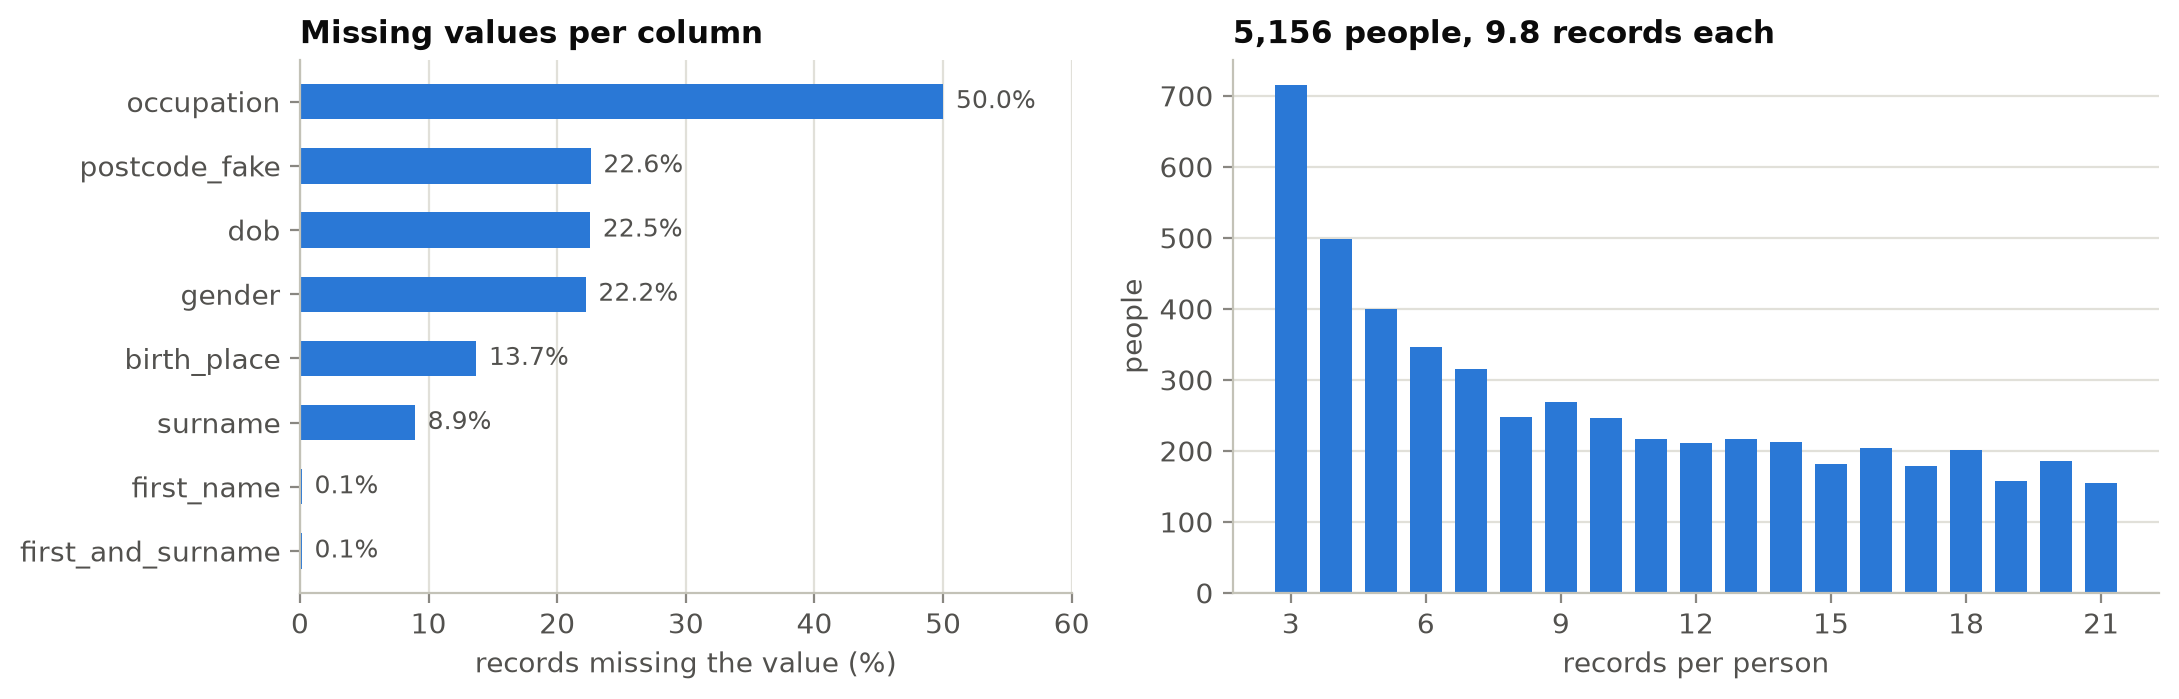

In [4]:
fields = ["first_name", "surname", "first_and_surname", "dob", "postcode_fake",
          "birth_place", "occupation", "gender"]
sizes = raw["cluster"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 1.2]})
missing = raw[fields].isna().mean().sort_values(ascending=False) * 100
y = hbars(ax1, missing.index, missing.values)
for yi, v in zip(y, missing.values):
    ax1.text(v + 1, yi, f"{v:.1f}%", va="center", fontsize=9, color=INK2)
ax1.set_xlim(0, 60)
ax1.set_xlabel("records missing the value (%)")
ax1.set_title("Missing values per column")

counts = sizes.value_counts().sort_index()
ax2.bar(counts.index, counts.values, width=0.7, color=BLUE)
ax2.set_xticks(range(3, sizes.max() + 1, 3))
ax2.set_xlabel("records per person")
ax2.set_ylabel("people")
ax2.set_title(f"{len(sizes):,} people, {sizes.mean():.1f} records each")
ax2.grid(axis="x", visible=False)
plt.tight_layout()

The pipeline reads a parquet file whose columns are typed the way the schema declares them, here every field a string and the id a string.
The truth goes to two csv files it never opens: one row per record with its entity, and one row per pair of records that are the same person, which is what `recall` and `cluster` score against.

In [5]:
data_path = WORK / "historical_50k.parquet"
truth_path = WORK / "historical_50k.truth.csv"

def as_string(series):
    "Every value a string, and empty or 'nan' a real null."
    s = series.astype(object).where(series.notna(), None)
    return s.map(lambda v: None if v in (None, "", "nan", "None") else str(v).strip())

columns = {"unique_id": as_string(raw["unique_id"]), **{f: as_string(raw[f]) for f in fields}}
table = pa.Table.from_pandas(pd.DataFrame(columns), schema=pa.schema([(c, pa.string()) for c in columns]))
pq.write_table(table, data_path)

pairs = [(a, b) for _, ids in raw.groupby("cluster")["unique_id"]
         for a, b in itertools.combinations(sorted(ids), 2)]
pd.DataFrame(pairs, columns=["id_a", "id_b"]).to_csv(truth_path, index=False)
truth_pairs = set(pairs)
print(f"{data_path}: {table.num_rows:,} rows x {table.num_columns} columns, "
      f"{data_path.stat().st_size / 1e6:.1f} MB")
print(f"{truth_path}: {len(pairs):,} known duplicate pairs")

work/historical_50k.parquet: 50,578 rows x 9 columns, 1.2 MB
work/historical_50k.truth.csv: 303,961 known duplicate pairs


## 2. A schema

`cpplink init` reads the parquet footer, guesses a role per column from its name and type, and writes a schema that runs.
It reads no rows: what a column is worth and where its thresholds go are `profile` and `levels`, further down.

In [6]:
draft, report = cpplink.init(data_path, roles={"birth_place": "city"})
print(report)

File         work/historical_50k.parquet
Unique id    unique_id

Column             Type         Role          Comparison
unique_id          string       id            unique_id
first_name         string       first_name    null / exact / levenshtein <= 1 / jaro_winkler >= 0.88 / else
surname            string       surname       null / exact / jaro_winkler >= 0.92 / jaro_winkler >= 0.85 / else
first_and_surname  string       full_name     null / exact / jaro_winkler >= 0.92 / jaro_winkler >= 0.85 / else
dob                string       birth_date    null / exact / levenshtein <= 1 / else
postcode_fake      string       postcode      null / exact / levenshtein <= 1 / else
birth_place        string       city*         null / exact / jaro_winkler >= 0.90 / else
occupation         string       text          null / exact / jaro_winkler >= 0.88 / else
gender             string       gender        null / exact / else

Blocking
  exact_value          dob                exact value
  exact_valu

`birth_place` was guessed as a birth date from the word `birth`, hence the override to `city`.
The draft is a fine starting point, but this notebook uses the schema the project's benchmark uses, so the numbers line up with `bench/`: the same eight comparisons as `null / exact / fuzzy... / else` ladders, term frequency on every one, and six blocking sources.
Four are exact agreement on a column, one is agreement on a rare full name (a value seen at most 20 times), and one is a sorted neighbourhood of 10 over the full name.

In [7]:
def ladder(*fuzzy):
    return [{"type": "null"}, {"type": "exact"}, *fuzzy, {"type": "else"}]

def jw(t):
    return {"type": "jaro_winkler", "threshold": t}

def lev(d):
    return {"type": "levenshtein", "threshold": d}

comparisons = {
    "first_name": ladder(jw(0.9), jw(0.8)),
    "surname": ladder(jw(0.9), jw(0.8)),
    "first_and_surname": ladder(jw(0.9), jw(0.8)),
    "dob": ladder(lev(1), lev(2)),
    "postcode_fake": ladder(lev(1)),
    "birth_place": ladder(jw(0.9)),
    "occupation": ladder(),
    "gender": ladder(),
}
schema = cpplink.Schema.from_dict({
    "unique_id": "unique_id",
    "columns": [{"name": f, "type": "string"} for f in fields],
    "comparisons": [{"name": c, "columns": [c], "term_frequency": True, "levels": levels}
                    for c, levels in comparisons.items()],
    "blocking": [
        {"type": "exact_value", "column": "dob"},
        {"type": "exact_value", "column": "surname"},
        {"type": "exact_value", "column": "postcode_fake"},
        {"type": "exact_value", "column": "first_name"},
        {"type": "rare_value", "column": "first_and_surname", "max_frequency": 20},
        {"type": "sorted_neighbourhood", "column": "first_and_surname", "window": 10},
    ],
})
schema.save(str(WORK / "schema.json"))
print(f"{len(schema.comparison_names)} comparisons packed into {schema.gamma_width} bits of gamma")

8 comparisons packed into 20 bits of gamma


The last line is the load-bearing design fact.
A pair enters the likelihood only through its agreement pattern $\gamma$, the vector of level indices, and eight ladders of three to five levels pack into 20 bits.
Estimation therefore needs a histogram over at most $2^{20}$ patterns rather than a table over the $10^{7}$ candidate pairs, and those pairs are generated, folded into the histogram, and discarded.

## 3. Load

A `Linker` is one loaded store and every stage over it.
Values are interned to dense integer ids per column at load, which is why the whole file is 13 MB resident and an exact comparison is an integer equality.

In [8]:
t = time.time()
linker = cpplink.Linker(schema, data_path)
timings["load"] = time.time() - t
print(linker)
print(linker.inspect())

Linker(50,578 records, 1 dataset, mode=all pairs)
Records      50,578
Row groups   1
Load time    0.0 s  (1,939,225 rows/s)

Column            Type                Distinct      Null   Top val Mean len        Rare pairs
---------------------------------------------------------------------------------------------
first_name        string                 4,413     0.13%     5.50%        -           289,577
surname           string                 6,195     8.93%     1.22%        -           440,461
first_and_surname string                20,479     0.13%     1.07%        -           115,782
dob               string                 8,985    22.55%     1.18%        -           186,217
postcode_fake     string                12,363    22.59%     0.07%        -           112,172
birth_place       string                 2,373    13.70%     4.59%        -           532,115
occupation        string                   453    50.00%     6.05%        -           146,142
gender            string     

## 4. Profile: what can these columns be worth?

Before any model, `profile` answers three questions from the rows alone.
How many bits can each column contribute, taking the collision rate of its values as $u$ and the best case $m = 1$?
How many of those bits are the same evidence twice, because two columns move together?
And what will a matching pair actually score, read off *anchor pairs*, pairs agreeing on a column set strong enough that the agreement alone makes them a match?

In [9]:
t = time.time()
profile = linker.profile()
timings["profile"] = time.time() - t

ledger = pd.DataFrame({
    "quantity": ["pair space", "prior odds", "available (m = 1)", "redundant (u side)", "margin",
                 "expected (m from anchors)", "double counted", "estimated margin"],
    "bits": [profile.space_bits, profile.prior_bits, profile.available_bits, -profile.redundant_bits,
             profile.margin_bits, profile.expected_bits, -profile.double_counted_bits,
             profile.estimated_margin_bits],
})
print(f"{profile.pair_space:,.0f} pairs in the unblocked space; "
      f"{profile.anchor_pairs:,} anchor pairs from {sum(s.used for s in profile.sessions)} anchors; {profile.seconds:.1f} s")
fmt(ledger, bits="{:+.2f}")

1,279,041,753 pairs in the unblocked space; 195,168 anchor pairs from 4 anchors; 0.1 s


quantity,bits
pair space,+30.25
prior odds,-14.63
available (m = 1),+47.30
redundant (u side),+1.29
margin,+31.38
expected (m from anchors),+33.05
double counted,+0.07
estimated margin,+18.35


The margin is what is left after the prior odds of two random records being the same person are paid.
The ceiling reads +31 bits; the anchor estimate, which is what a match will actually score, reads +18.
Both are comfortably positive, so the columns can separate the two classes.
Per column, the three readings are the ceiling, the ceiling weighted by how often the value is present, and the anchor estimate.

name,distinct,nulls,top_share,effective_values,bits,covered_bits,sessions,pairs,m,m_low,m_high,weight,expected_bits
postcode_fake,"12,363","11,426",0.09%,"6,833",12.74,7.63,1,"30,387",0.748,0.748,0.748,12.32,6.86
first_and_surname,"20,479",67,1.07%,"4,862",12.25,12.21,1,"42,994",0.529,0.529,0.529,11.33,5.47
surname,"6,195","4,515",1.34%,"1,447",10.50,8.71,1,"38,888",0.821,0.821,0.821,10.21,7.17
dob,"8,985","11,403",1.52%,495,8.95,5.37,2,"84,543",0.652,0.625,0.680,8.34,3.65
birth_place,"2,373","6,927",5.32%,193,7.60,5.66,4,"166,523",0.858,0.840,0.865,7.37,5.06
first_name,"4,413",67,5.50%,78,6.28,6.27,1,"70,759",0.595,0.595,0.595,5.53,2.77
occupation,453,"25,289",12.10%,25,4.67,1.17,4,"95,591",0.909,0.897,0.914,4.53,1.87
gender,7,"11,230",83.60%,1,0.46,0.28,4,"149,594",0.951,0.942,0.957,0.39,0.19


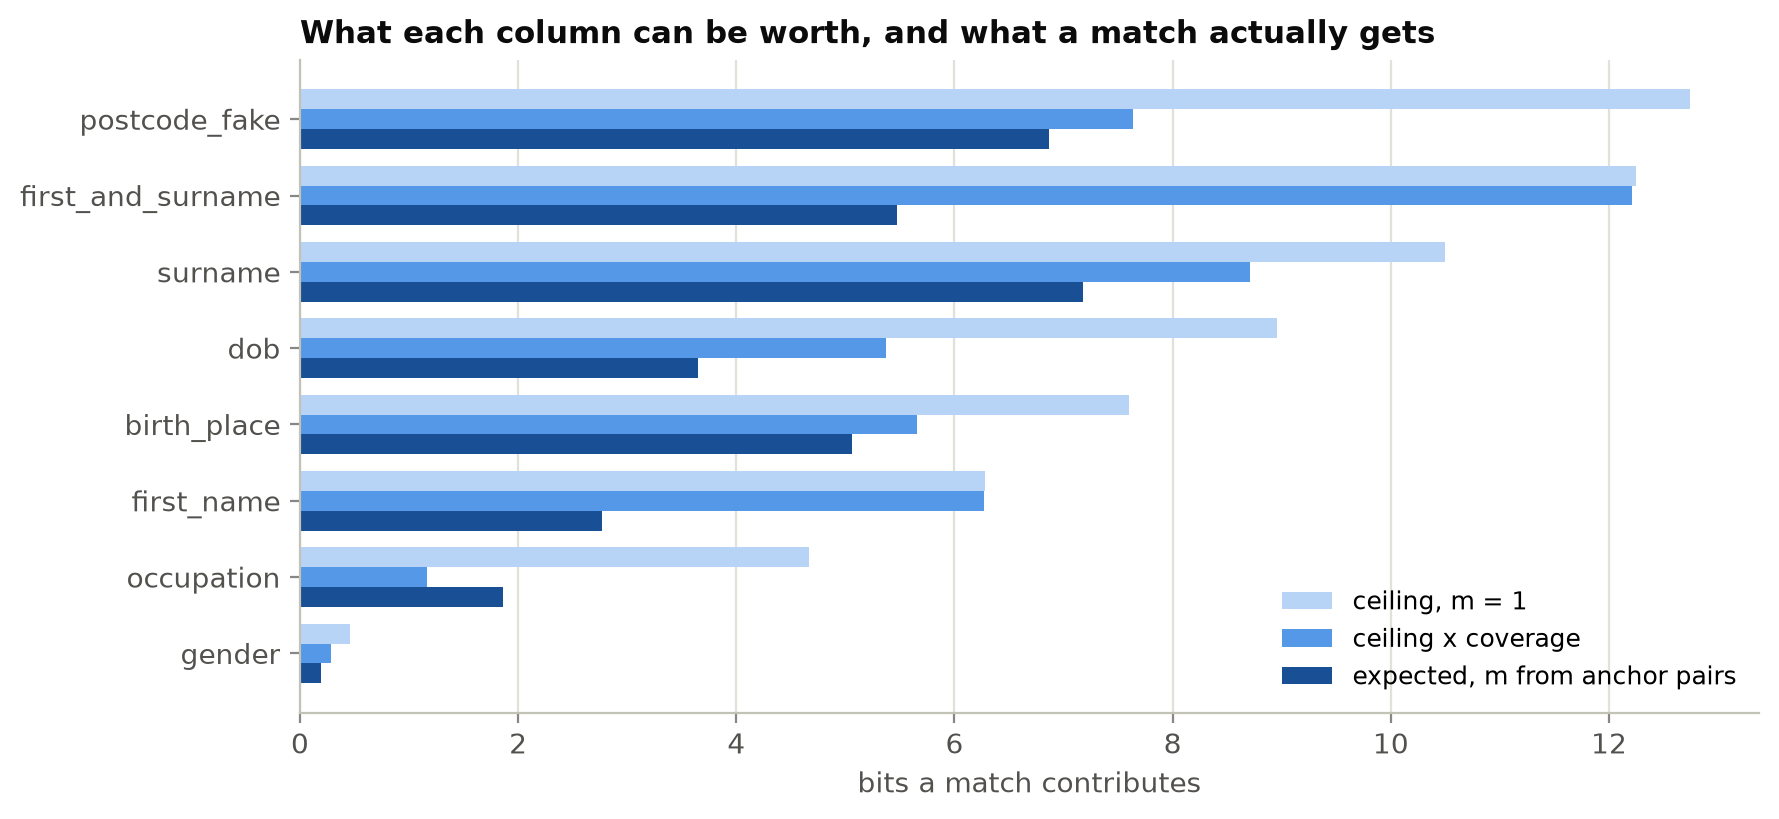

In [10]:
cols = frame(profile.columns, ["name", "distinct", "nulls", "top_share", "effective_values", "bits", "covered_bits"])
matches = frame(profile.matches, ["name", "sessions", "pairs", "m", "m_low", "m_high", "weight", "expected_bits"])
cols = cols.merge(matches, on="name").sort_values("bits", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(cols))[::-1]
h = 0.26
ax.barh(y + h, cols["bits"], height=h, color="#b7d3f6", label="ceiling, m = 1")
ax.barh(y, cols["covered_bits"], height=h, color="#5598e7", label="ceiling x coverage")
ax.barh(y - h, cols["expected_bits"], height=h, color="#184f95", label="expected, m from anchor pairs")
ax.set_yticks(y, cols["name"])
ax.grid(axis="y", visible=False)
ax.set_xlabel("bits a match contributes")
ax.set_title("What each column can be worth, and what a match actually gets")
ax.legend(loc="lower right")
plt.tight_layout()

fmt(cols, top_share="{:.2%}", effective_values="{:,.0f}", bits="{:.2f}", covered_bits="{:.2f}",
    m="{:.3f}", m_low="{:.3f}", m_high="{:.3f}", weight="{:.2f}", expected_bits="{:.2f}")

`postcode_fake` has 12,363 distinct values and behaves as 6,833; `surname` has 6,195 and behaves as 1,447; `first_name` has 4,413 and behaves as 78, because the common names are very common.
That is the difference between a distinct count and an effective cardinality, and it is why the profile reads the term frequencies rather than counting values.

The second question is dependence.
The profile's `L->R` is the share of rows kept when each value of the left column is mapped to its commonest right partner, so a column that *determines* another reads 1; below it is read above the target's baseline, since a column with one dominant value is determined by everything.

left_name,right_name,rows,determines_right,determines_left,containment
first_name,first_and_surname,"50,511",0.234,1.000,1.000
surname,first_and_surname,"46,063",0.514,1.000,1.000


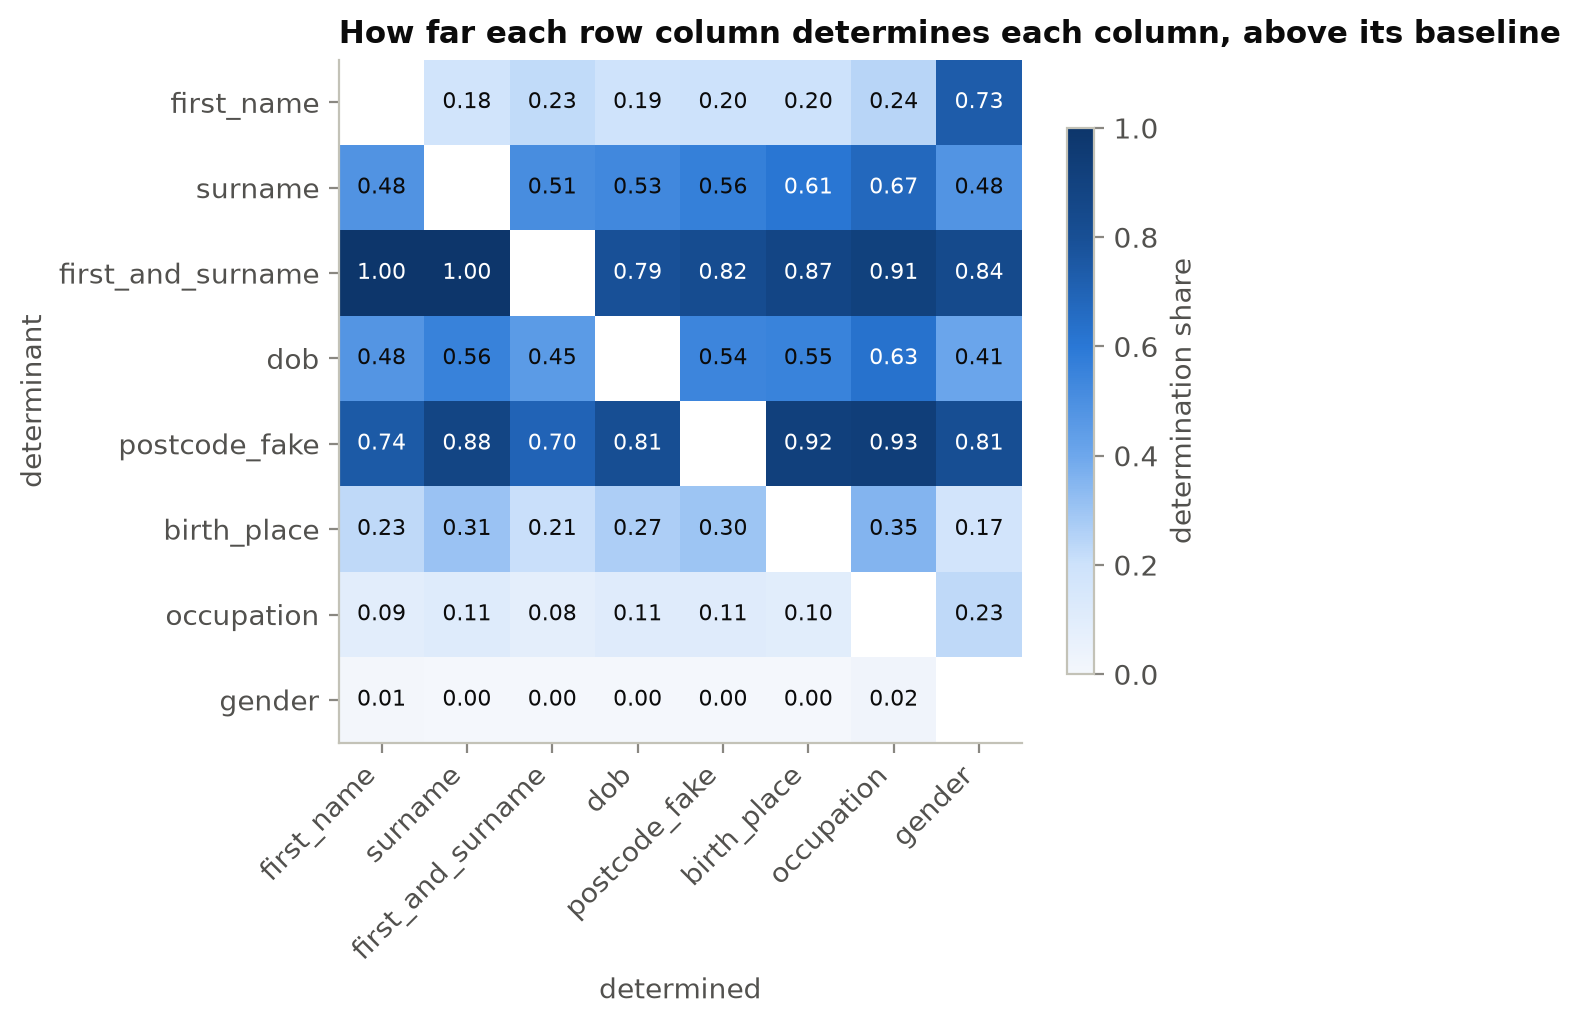

In [11]:
pairs_df = frame(profile.pairs)
names = [c.name for c in profile.columns]
det = pd.DataFrame(np.nan, index=names, columns=names)
for _, p in pairs_df.iterrows():
    # The share above the target's own baseline: a column with one dominant value is "determined" by
    # everything, so the raw share is read against what a constant mapping already keeps.
    det.loc[p.left_name, p.right_name] = (p.determines_right - p.baseline_right) / (1 - p.baseline_right)
    det.loc[p.right_name, p.left_name] = (p.determines_left - p.baseline_left) / (1 - p.baseline_left)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(det.values, cmap=BLUES, vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=45, ha="right")
ax.set_yticks(range(len(names)), names)
ax.grid(False)
for i in range(len(names)):
    for j in range(len(names)):
        v = det.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.6 else INK)
ax.set_title("How far each row column determines each column, above its baseline")
ax.set_xlabel("determined")
ax.set_ylabel("determinant")
plt.colorbar(im, ax=ax, shrink=0.8, label="determination share")
plt.tight_layout()

suspects = pairs_df[(pairs_df.determines_right >= 0.99) | (pairs_df.determines_left >= 0.99)]
suspects = suspects[suspects.left_informative | suspects.right_informative]
fmt(suspects[["left_name", "right_name", "rows", "determines_right", "determines_left", "containment"]],
    determines_right="{:.3f}", determines_left="{:.3f}", containment="{:.3f}")

`first_and_surname` determines both `first_name` and `surname` on every row, and contains them as substrings: they are the same evidence twice.
The estimator below knows this, and holds the tied comparisons out of every EM session that blocks on one of them.
Without that, the `first_name` session reads a match rate of 0.9996 where the truth is 0.008, because "john smith" against "john brown" clears `jaro_winkler >= 0.80` on the shared token alone.

## 5. Blocking: how many pairs, and which of the right ones

Blocking decides which of the 1.28 billion pairs are compared at all.
`explain_blocking` prices every source exactly from the term frequencies, without enumerating a pair; `count=True` also enumerates the deduplicated union to check.
`recall` then scores each source against the known pairs: pair completeness (the share of true pairs reached), pair quality (true pairs per candidate) and the marginal pair quality of what the source alone reaches.

In [12]:
t = time.time()
blocking = linker.explain_blocking(count=True)
recall = linker.recall(truth_path, why=True, show_misses=3)
timings["blocking + recall"] = time.time() - t
m = recall.metrics

sources = frame(blocking.sources, ["name", "kind", "column", "pairs", "largest_group"])
found = frame(m.sources, ["name", "found", "first_to"])
sources = sources.merge(found, on="name")
sources["PC"] = sources["found"] / m.truth_pairs
sources["PQ"] = sources["found"] / sources["pairs"]
sources["marginal PQ"] = sources["first_to"] / sources["pairs"]
print(f"union {blocking.candidate_union:,} candidate pairs ({blocking.candidate_union / m.pair_space:.2%} of the space), "
      f"{m.union_found:,} of {m.truth_pairs:,} known pairs reached: pair completeness {m.pair_completeness:.2%}")
fmt(sources, PC="{:.2%}", PQ="{:.2%}", **{"marginal PQ": "{:.2%}"})

union 18,436,900 candidate pairs (1.44% of the space), 258,329 of 303,961 known pairs reached: pair completeness 84.99%


name,kind,column,pairs,largest_group,found,first_to,PC,PQ,marginal PQ
dob exact_value,exact_value,dob,"1,549,081",596,"90,760","90,760",29.86%,5.86%,5.86%
surname exact_value,exact_value,surname,"733,085",615,"182,304","120,480",59.98%,24.87%,16.43%
postcode_fake exact_value,exact_value,postcode_fake,"112,172",34,"105,489","23,943",34.70%,94.04%,21.34%
first_name exact_value,exact_value,first_name,"16,372,982","2,780","130,700","21,624",43.00%,0.80%,0.13%
first_and_surname rare_value,rare_value,first_and_surname,"97,067",20,"88,072",0,28.97%,90.73%,0.00%
first_and_surname sorted_neighbourhood,sorted_neighbourhood,first_and_surname,"505,055",11,"116,433","1,522",38.31%,23.05%,0.30%


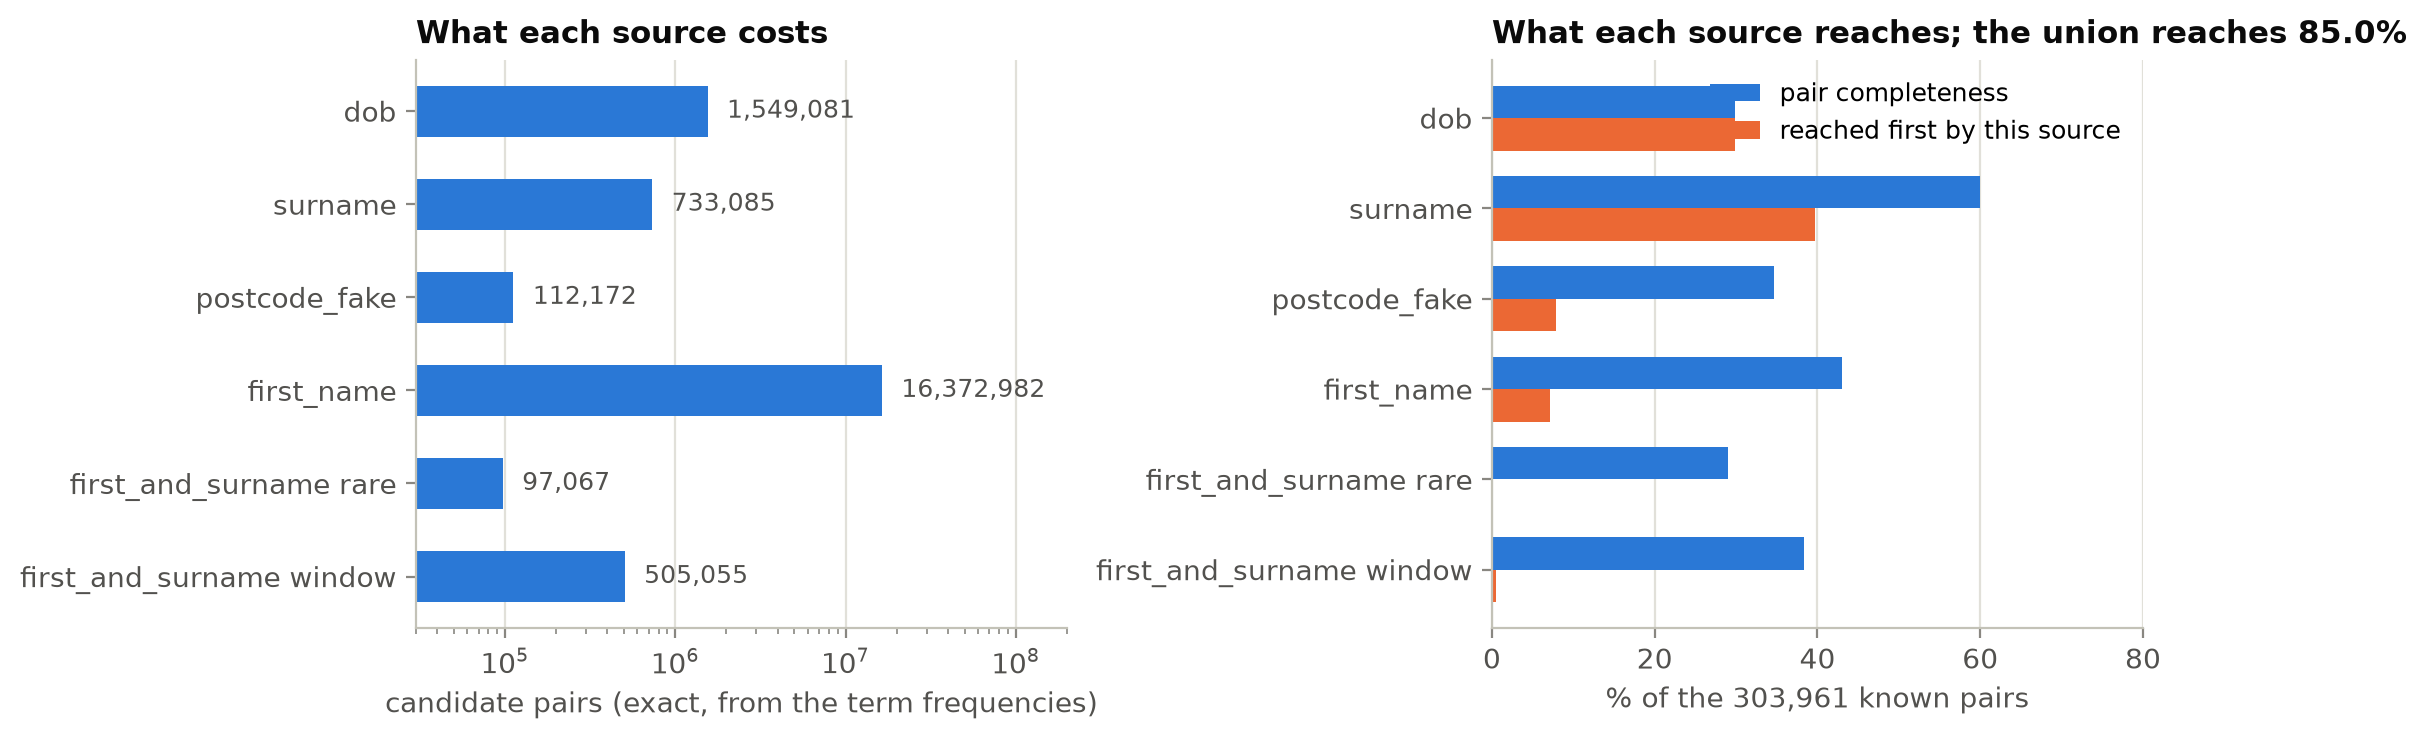

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
labels = [n.replace(" exact_value", "").replace("_value", "").replace("sorted_neighbourhood", "window")
          for n in sources["name"]]
y = hbars(ax1, labels, sources["pairs"], color=BLUE)
ax1.set_xscale("log")
for yi, v in zip(y, sources["pairs"]):
    ax1.text(v * 1.3, yi, f"{v:,}", va="center", fontsize=9, color=INK2)
ax1.set_xlim(3e4, 2e8)
ax1.set_xlabel("candidate pairs (exact, from the term frequencies)")
ax1.set_title("What each source costs")

h = 0.36
y2 = np.arange(len(labels))[::-1]
ax2.barh(y2 + h / 2, sources["PC"] * 100, height=h, color=BLUE, label="pair completeness")
ax2.barh(y2 - h / 2, sources["first_to"] / m.truth_pairs * 100, height=h, color=ORANGE, label="reached first by this source")
ax2.set_yticks(y2, labels)
ax2.grid(axis="y", visible=False)
ax2.set_xlabel("% of the 303,961 known pairs")
ax2.set_xlim(0, 80)
ax2.set_title(f"What each source reaches; the union reaches {m.pair_completeness:.1%}")
ax2.legend(loc="upper right")
plt.tight_layout()

`first_name` reaches 43% of the true pairs for 16 million candidates, and only 0.13% of those are pairs no earlier source produced: that is the number a source gets dropped on.
`postcode_fake` reaches 35% for 112 thousand, at 94% pair quality.

15% of the known pairs are reached by no source, and no amount of scoring recovers a pair that is never a candidate.
`why=True` classifies every missed pair per source: the value was null, the values disagreed, the value was too common for the cap, or the pair sat outside the window.

3,875 would be reached by a wider window, 41,757 need a signal the plan does not carry, 3,664 agree on no column at all


comparison,exact,fuzzy,blocked
first_name,0,"11,761",True
surname,0,"12,375",True
first_and_surname,0,"12,305",True
dob,0,"15,067",True
postcode_fake,0,"3,360",True
birth_place,"20,645",267,False
occupation,"7,683",0,False
gender,"17,390",0,False


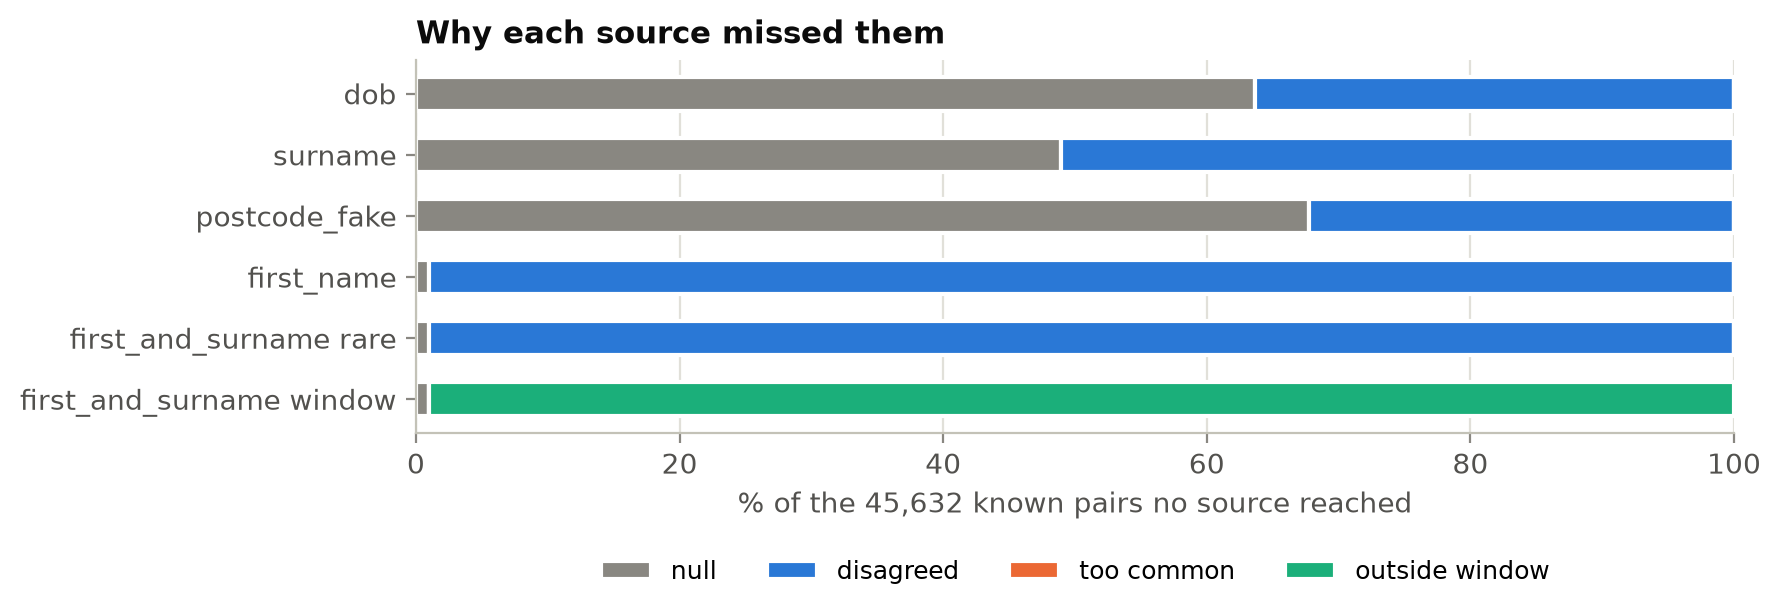

In [14]:
misses = recall.misses
reasons = pd.DataFrame(misses.reasons, index=[s.name for s in m.sources], columns=misses.reason_names)
reasons = reasons.drop(columns=["produced"]) / misses.missed * 100

fig, ax = plt.subplots(figsize=(9, 3.4))
left = np.zeros(len(reasons))
y = np.arange(len(reasons))[::-1]
for reason, color in zip(reasons.columns, [MUTED, BLUE, ORANGE, AQUA]):
    ax.barh(y, reasons[reason], left=left, height=0.55, color=color, label=reason, edgecolor="white", linewidth=1.5)
    left += reasons[reason].values
ax.set_yticks(y, labels)
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"% of the {misses.missed:,} known pairs no source reached")
ax.set_xlim(0, 100)
ax.set_title("Why each source missed them")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4)
plt.tight_layout()

agreement = frame(misses.agreement)
print(f"{misses.fixable_by_window:,} would be reached by a wider window, "
      f"{misses.unreachable:,} need a signal the plan does not carry, "
      f"{misses.agreed_on_nothing:,} agree on no column at all")
fmt(agreement)

Of the unreachable pairs, half still agree exactly on `birth_place` and 42% on `gender`, neither of which is blocked on; the blocked columns disagree by construction.
A source on `birth_place` would reach them, but on this data reaching more pairs is not reaching better ones: the project measured a Soundex source on `surname` taking completeness from 85% to 88% and F1 *down* by 0.002, because the new candidates fail the threshold and cost a few false positives that clear it.
Every source added should be measured this way first.

## 6. Levels: where should the fuzzy thresholds sit?

The schema says `jaro_winkler >= 0.90` and `>= 0.80` because those are the customary numbers.
`levels` measures two curves per comparison: $u(t)$, the probability two random values are at least $t$ similar, which is exact because interning turns it into a sweep over the column's dictionary self-join; and $m(t)$, the same over anchor pairs.
It then places the cuts by maximising the divergence between the two, at the level count the schema already has.

comparison,anchor,anchor pairs,current,proposed,current bits,proposed bits
first_name,surname + postcode_fake,"70,759",jaro_winkler >= 0.90 / jaro_winkler >= 0.80,jaro_winkler >= 0.84 / jaro_winkler >= 0.75,3.76,3.87
surname,dob + postcode_fake,"38,888",jaro_winkler >= 0.90 / jaro_winkler >= 0.80,jaro_winkler >= 0.90 / jaro_winkler >= 0.83,8.95,8.96
first_and_surname,dob + postcode_fake,"42,994",jaro_winkler >= 0.90 / jaro_winkler >= 0.80,jaro_winkler >= 0.93 / jaro_winkler >= 0.75,7.42,7.80
dob,surname + postcode_fake,"51,098",levenshtein <= 1 / levenshtein <= 2,levenshtein <= 1 / levenshtein <= 2,6.46,6.46
postcode_fake,first_and_surname + dob,"30,387",levenshtein <= 1,levenshtein <= 2,9.44,9.67
birth_place,surname + postcode_fake,"58,622",jaro_winkler >= 0.90,jaro_winkler >= 0.88,5.80,5.81


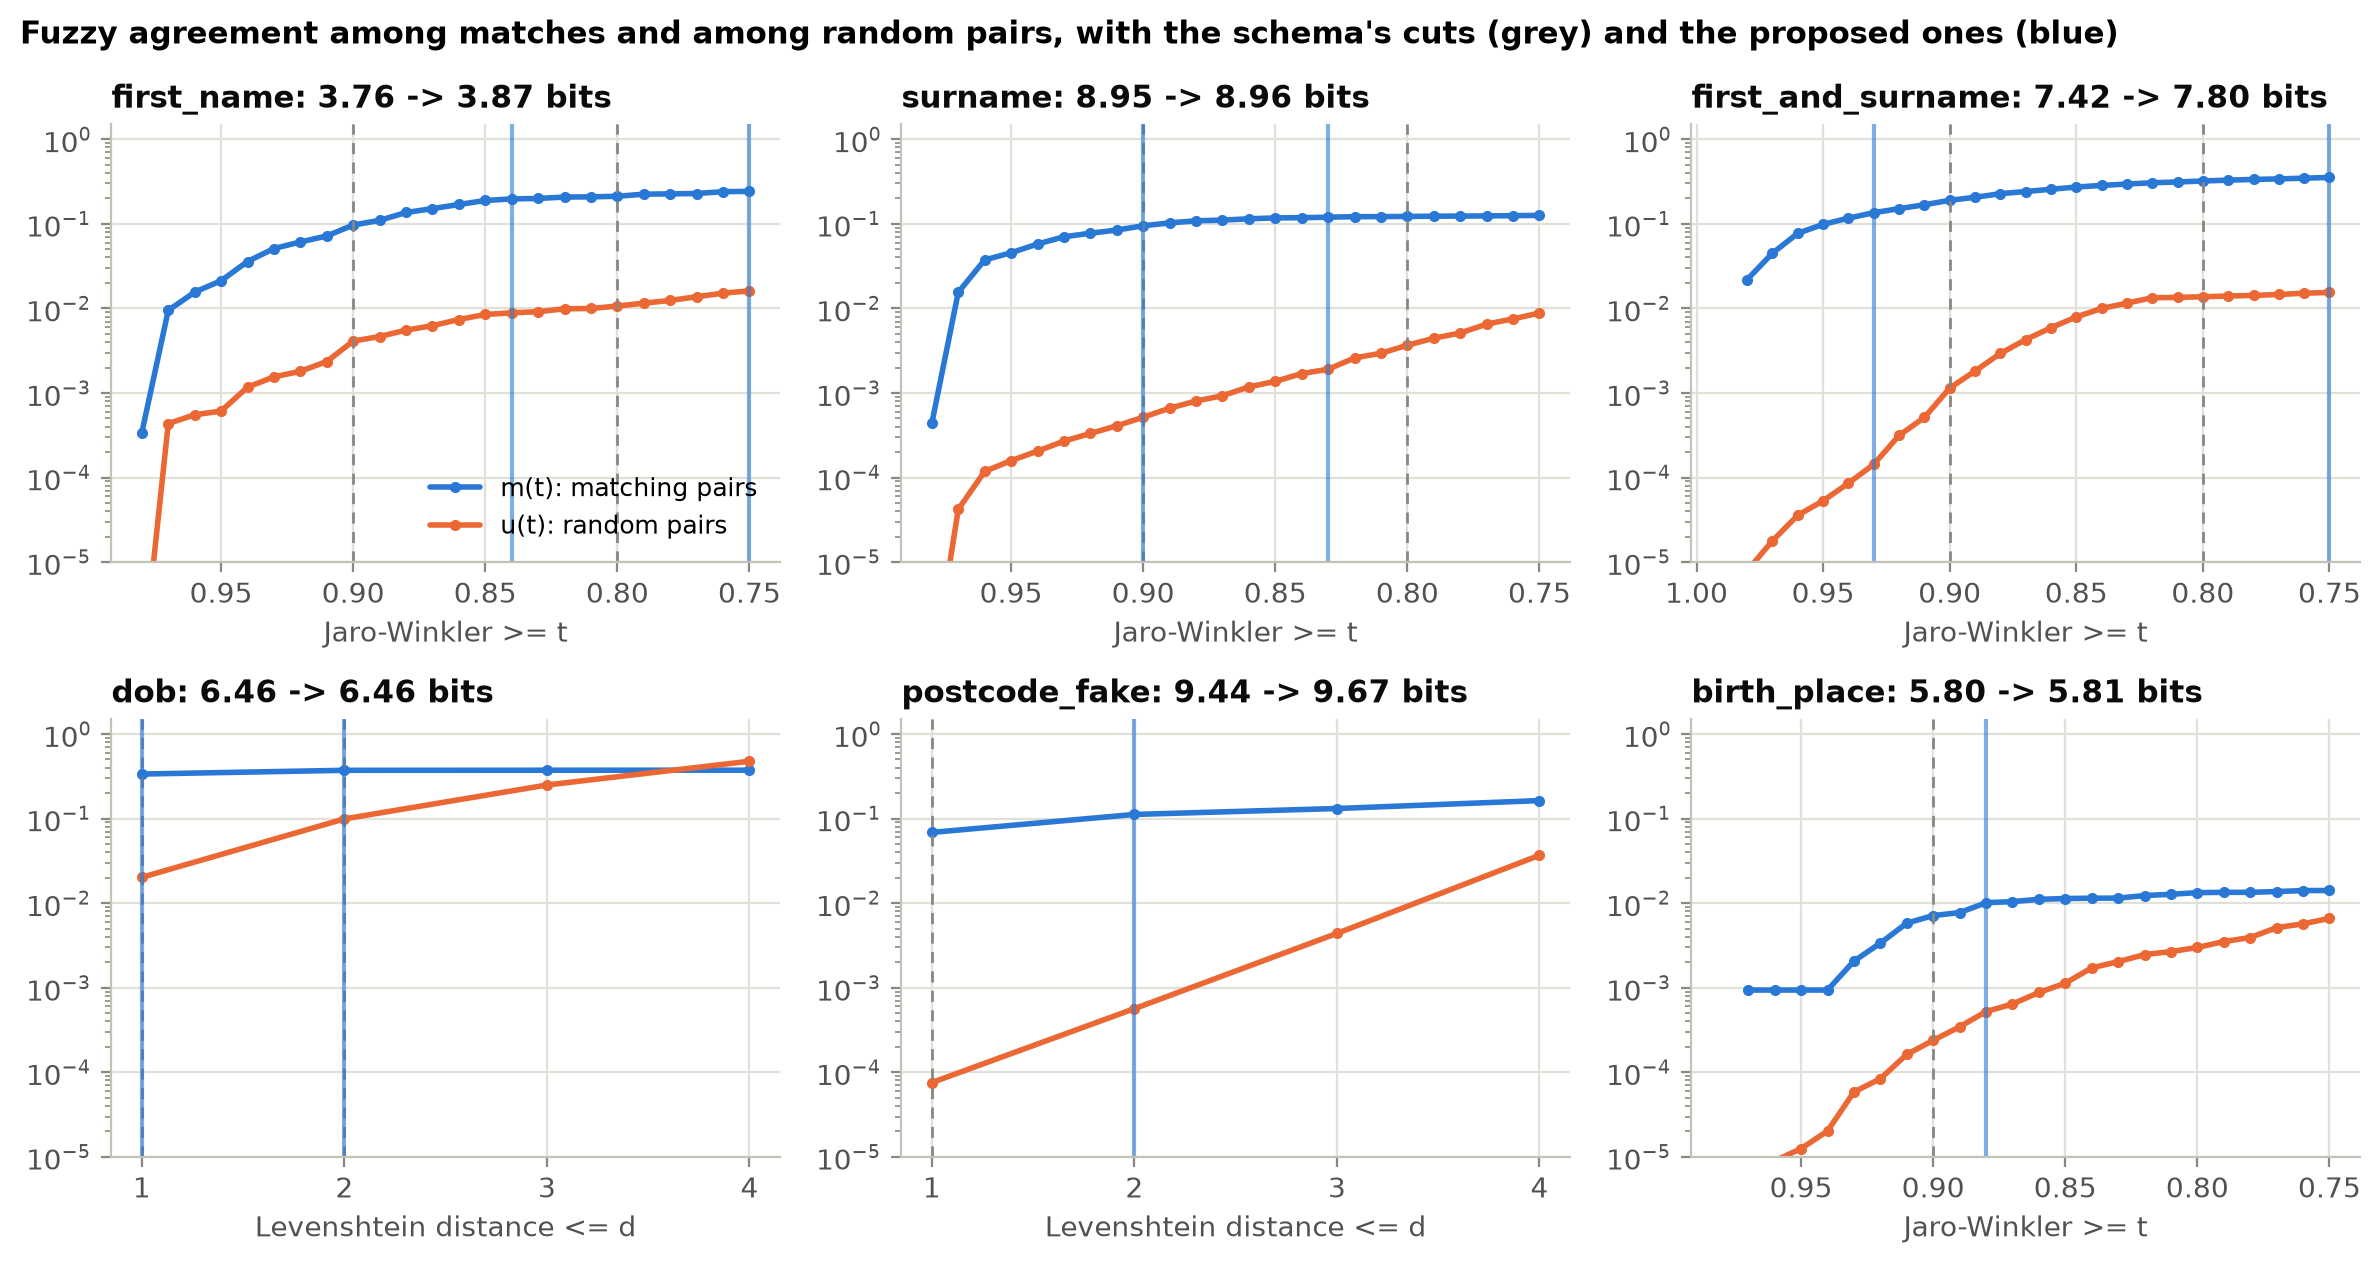

In [15]:
t = time.time()
levels, proposal = linker.levels()
timings["levels"] = time.time() - t

fuzzy = [c for c in levels.comparisons if c.proposed]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, c in zip(axes.flat, fuzzy):
    bins = frame(c.bins)
    body = bins[~bins["exact"] & ~bins["tail"]]
    lev = c.metric == "levenshtein"
    # P(sim >= t) for Jaro-Winkler, P(distance <= d) for Levenshtein: a cumulative mass over the fuzzy bins.
    x = body.threshold.values
    ax.plot(x, body.m.cumsum().replace(0, np.nan), color=BLUE, marker="o", markersize=3, label="m(t): matching pairs")
    ax.plot(x, body.u.cumsum().replace(0, np.nan), color=ORANGE, marker="o", markersize=3, label="u(t): random pairs")
    for lvl in c.current[1:-1]:
        ax.axvline(lvl.threshold, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    for lvl in c.best[1:-1]:
        ax.axvline(lvl.threshold, color=BLUE, linewidth=1.5, alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylim(1e-5, 1.5)
    if lev:
        ax.set_xticks(x.astype(int))
        ax.set_xlabel("Levenshtein distance <= d")
    else:
        ax.set_xlabel("Jaro-Winkler >= t")
        ax.invert_xaxis()
    ax.set_title(f"{c.name}: {c.current_bits:.2f} -> {c.best_bits:.2f} bits")
axes[0, 0].legend(loc="lower right")
fig.suptitle("Fuzzy agreement among matches and among random pairs, with the schema's cuts (grey) and the proposed ones (blue)",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()

fmt(pd.DataFrame({
    "comparison": [c.name for c in fuzzy],
    "anchor": [" + ".join(c.anchor) for c in fuzzy],
    "anchor pairs": [c.match_pairs for c in fuzzy],
    "current": [" / ".join(l.label for l in c.current[1:-1]) for c in fuzzy],
    "proposed": [" / ".join(l.label for l in c.best[1:-1]) for c in fuzzy],
    "current bits": [c.current_bits for c in fuzzy],
    "proposed bits": [c.best_bits for c in fuzzy],
}), **{"current bits": "{:.2f}", "proposed bits": "{:.2f}"})

The proposal is worth 0.75 bits per match across the six comparisons, most of it on `first_and_surname`, a two-token field carrying a one-token field's thresholds.
The project measured what this buys end to end: on this dataset the best F1 moves from 0.8606 to 0.8617, and what the bits actually buy is robustness to where the threshold is put rather than a higher peak.
`proposal` is a `Schema` with the new cuts written in; this notebook keeps the schema's cuts so the numbers stay comparable with the benchmark.

## 7. Estimate: learn $m$, $u$ and $\lambda$

$u$, the agreement rate among non-matching pairs, never sees a candidate pair: the null and exact levels are closed form from the term frequencies, and the fuzzy levels are sampled from a million uniformly random pairs.
$m$ comes from EM, one session per column an EM-safe source blocks on.
Each session enumerates that source's pairs, folds them into a pattern histogram, holds out every comparison reading the blocked column or one tied to it, and runs EM on the histogram, so its cost is the number of distinct patterns rather than the number of pairs.
The sessions' $m$ are averaged, and $\lambda$ is what the largest session implies.

In [16]:
t = time.time()
model, estimate = linker.estimate(out=WORK / "model.json", seed=7)
timings["estimate"] = time.time() - t

sessions = frame(estimate.sessions, ["column", "sources", "excluded", "tied", "enumerated", "folded",
                                     "distinct", "iterations", "lambda_", "implied_matches"])
sessions["fit bits/pair"] = [s.fit.bits for s in estimate.sessions]
sessions["sources"] = sessions["sources"].str.join(", ")
sessions["tied"] = sessions["tied"].str.join(", ")
sessions["excluded"] = sessions["excluded"].str.join(", ")
print(f"u from {estimate.u_pairs:,} random pairs plus {estimate.u_exact_levels} levels in closed form; "
      f"lambda {model.lambda_:.3e}, prior weight {model.prior_weight():+.2f} bits; {timings['estimate']:.1f} s")
for w in estimate.warnings:
    print("warning:", w)
fmt(sessions, lambda_="{:.4f}", implied_matches="{:,.0f}", **{"fit bits/pair": "{:.3f}"})

u from 999,987 random pairs plus 16 levels in closed form; lambda 2.706e-04, prior weight -11.85 bits; 1.2 s


column,sources,excluded,tied,enumerated,folded,distinct,iterations,lambda_,implied_matches,fit bits/pair
dob,dob exact_value,dob,,"1,549,081","1,549,081","3,209",31,0.0603,"93,344",0.402
surname,surname exact_value,surname,first_and_surname,"733,085","733,085","3,344",20,0.4721,"346,117",0.568
postcode_fake,postcode_fake exact_value,postcode_fake,,"112,172","112,172","3,181",12,0.9282,"104,116",1.779
first_name,first_name exact_value,first_name,"first_and_surname, occupation, gender","16,372,982","10,001,090","3,573",62,0.0180,"294,750",0.193
first_and_surname,"first_and_surname rare_value, first_and_surname sorted_neighbourhood",first_and_surname,"first_name, surname","506,552","506,552","5,567",15,0.2208,"111,823",0.187


The `first_name` session compared 10 million of its 16 million pairs, a Bernoulli sample of the stream that needs no reweighting because $m$, $u$ and $\lambda$ are all ratios of pattern counts.
The warning is the standing limit of a blocked estimator: $\lambda$ counts only the matches blocking reached, so it is a lower bound.

The model itself is a table: for every level of every comparison, $m$, $u$ and the weight $\log_2(m/u)$, the bits a pair gains or loses by landing on that level.

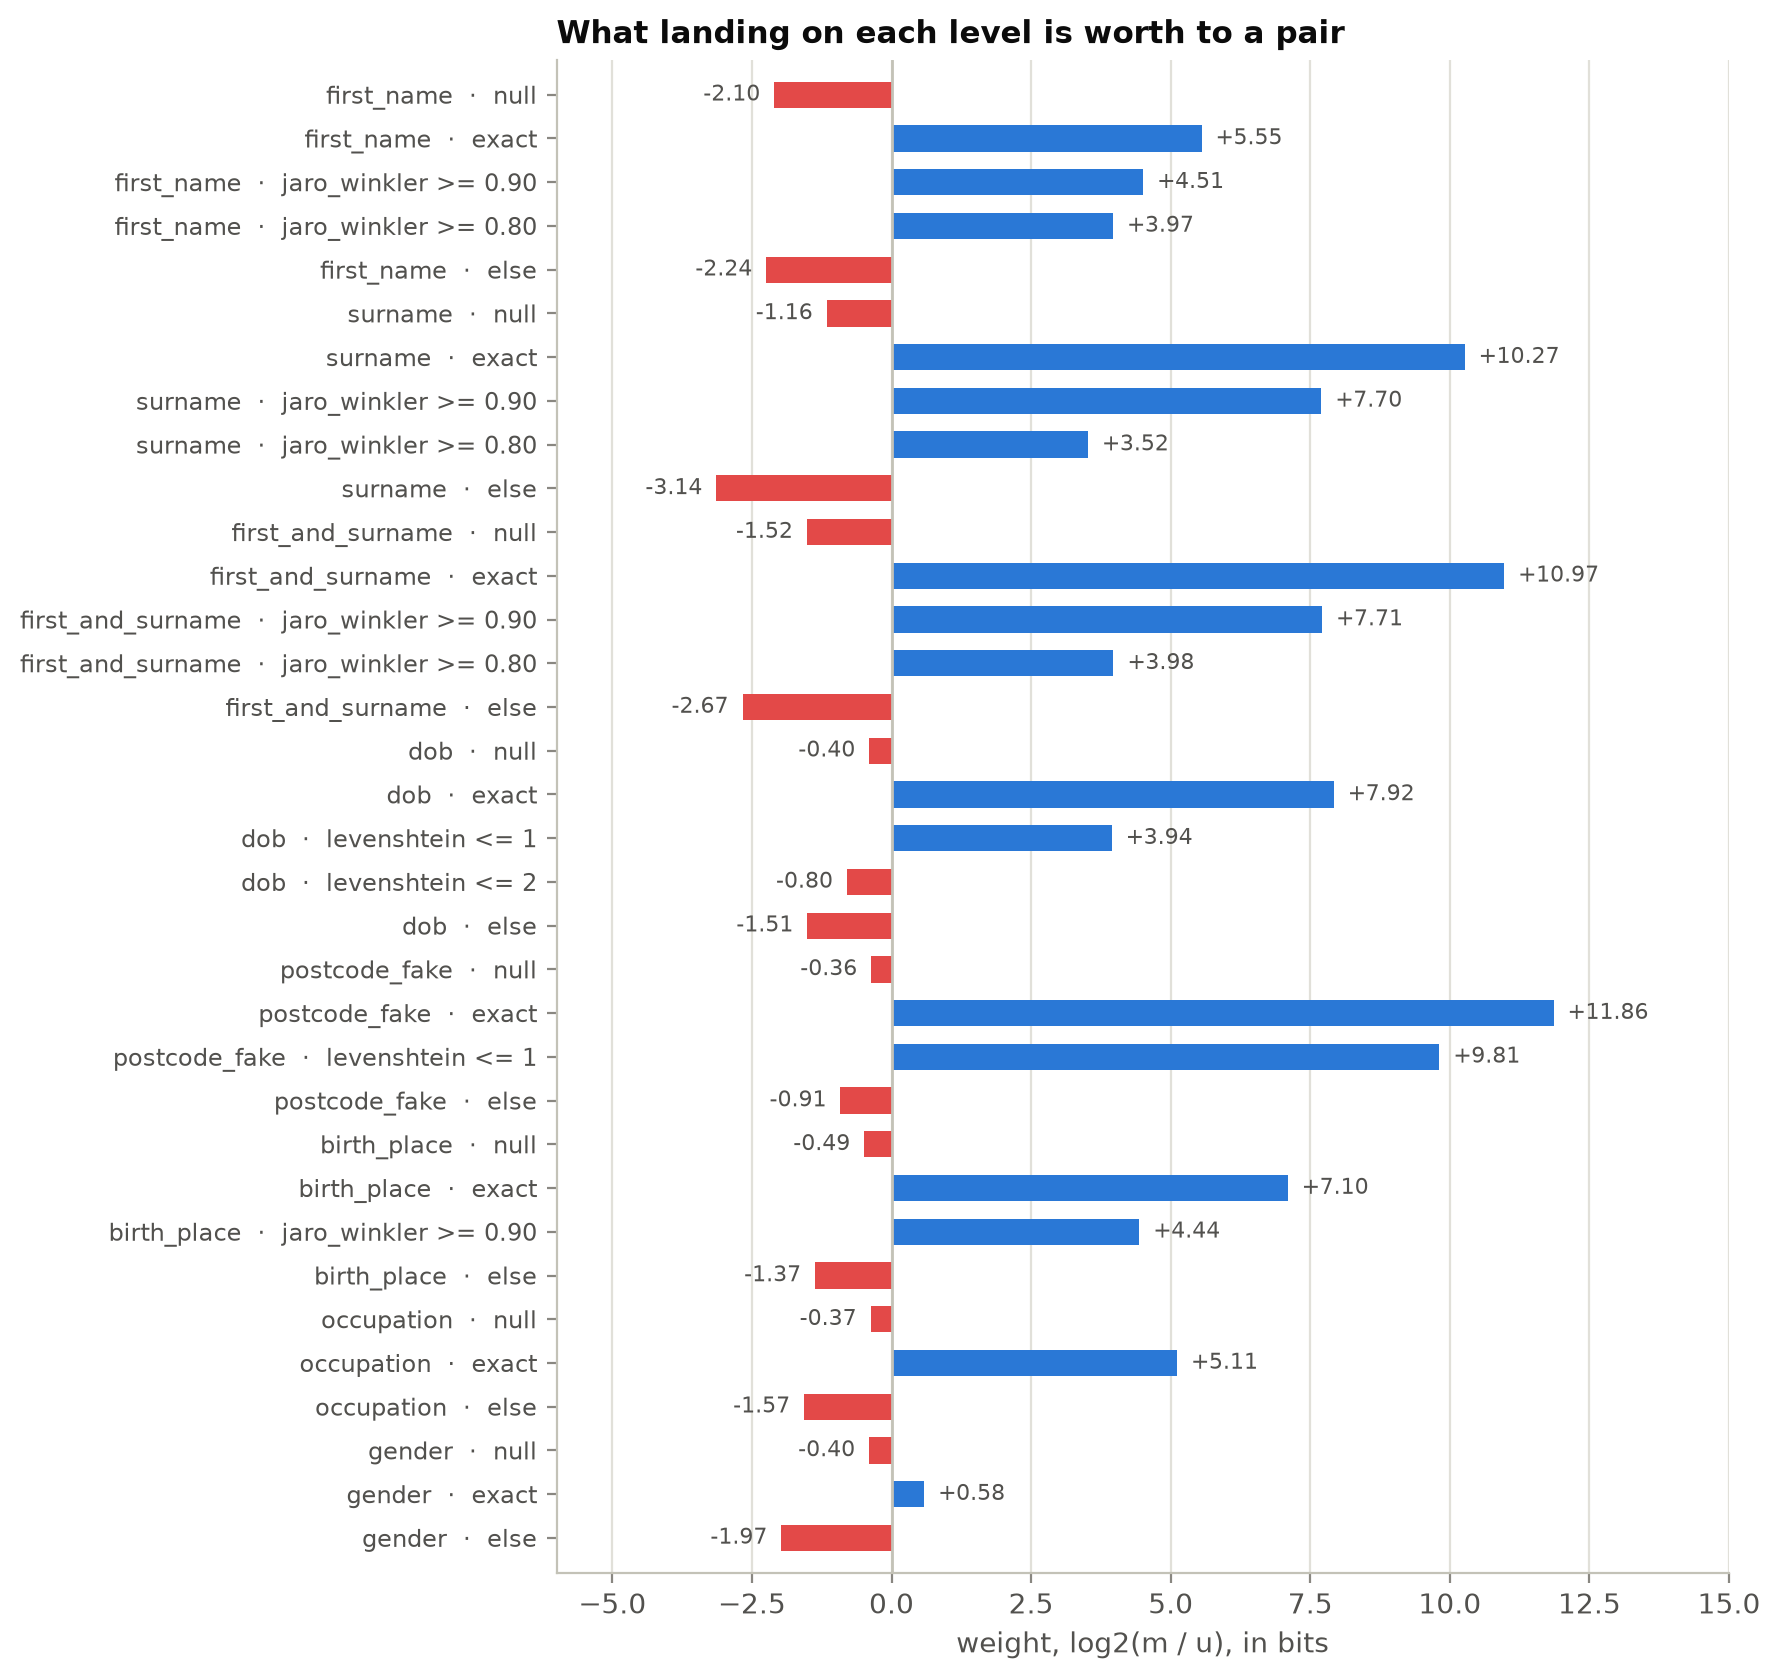

In [17]:
def level_table(model):
    rows = []
    for c in model.comparisons:
        for i, l in enumerate(c.levels):
            rows.append({"comparison": c.name, "level": l.label, "m": l.m, "u": l.u,
                         "weight": np.log2(l.m / l.u), "u exact": l.u_exact})
    return pd.DataFrame(rows)

weights = level_table(model)

fig, ax = plt.subplots(figsize=(9, 8.5))
y = np.arange(len(weights))[::-1]
colors = [BLUE if w > 0 else RED for w in weights["weight"]]
ax.barh(y, weights["weight"], height=0.6, color=colors)
ax.set_yticks(y, [f"{c}  ·  {l}" for c, l in zip(weights["comparison"], weights["level"])], fontsize=8.5)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("weight, log2(m / u), in bits")
ax.set_title("What landing on each level is worth to a pair")
for yi, w in zip(y, weights["weight"]):
    ax.text(w + (0.25 if w > 0 else -0.25), yi, f"{w:+.2f}", va="center",
            ha="left" if w > 0 else "right", fontsize=8, color=INK2)
ax.set_xlim(-6, 15)
ax.set_ylim(-0.8, len(weights) - 0.2)
plt.tight_layout()

An exact postcode is worth +11.9 bits and an exact surname +10.3, against a prior of -11.9: two such agreements make a match on their own.
Disagreement costs little, one to three bits, because on this data a matching pair disagrees on some field more often than not.
Agreeing on gender is worth +0.6 bits, which is what a two-valued column can be.

`estimate` also says whether the mixture fits.
For each session it predicts every pattern's count under conditional independence and reports the deviance in bits per pair, with the same over every pair of comparisons as a residual: where conditional independence fails.

In [18]:
residuals = pd.concat([frame(s.fit.residuals).assign(session=s.column) for s in estimate.sessions])
worst = (residuals.groupby(["left", "right"])["bits"].max().sort_values(ascending=False).head(8)
         .rename("worst residual, bits per pair").reset_index())
fmt(worst, **{"worst residual, bits per pair": "{:.3f}"})

left,right,"worst residual, bits per pair"
first_name,first_and_surname,0.754
surname,first_and_surname,0.325
dob,birth_place,0.149
dob,postcode_fake,0.133
surname,postcode_fake,0.101
surname,dob,0.098
postcode_fake,birth_place,0.096
surname,birth_place,0.089


### With two-way interactions

The two worst residuals are the two ties the profile found from the rows.
`interactions=True` corrects the dependence inside the scoring model: the weight gains a term $\delta_{cd}(\gamma_c, \gamma_d)$ per admitted pair of comparisons, the log ratio of their joint agreement to the product of the margins among matches, less the same among non-matches.
It is fitted to the model's own margins, so it moves no $m$ or $u$ and carries only the association.

In [19]:
t = time.time()
model_x, estimate_x = linker.estimate(out=WORK / "model_interactions.json", seed=7, interactions=True)
timings["estimate, interactions"] = time.time() - t

candidates = frame(estimate_x.interactions.candidates,
                   ["left", "right", "effect", "match_bits", "weakest", "contamination", "sessions", "admitted", "reason"])
print(f"{estimate_x.interactions.admitted} of {len(candidates)} candidate pairs entered the model")
fmt(candidates.head(6), effect="{:.2f}", match_bits="{:+.2f}", weakest="{:+.2f}", contamination="{:.0%}")

2 of 28 candidate pairs entered the model


left,right,effect,match_bits,weakest,contamination,sessions,admitted,reason
first_name,first_and_surname,4.25,-2.88,-2.87,31%,2,True,
surname,first_and_surname,3.74,-3.29,-3.25,40%,2,True,
first_name,surname,1.85,-1.68,-1.63,41%,2,False,past --max-interactions
dob,birth_place,0.55,+0.31,+0.05,27%,4,False,one session moves a match by only 0.05 bits
postcode_fake,birth_place,0.48,-0.15,-0.14,32%,4,False,one session moves a match by only -0.14 bits
dob,postcode_fake,0.47,-0.06,+0.00,27%,3,False,two sessions disagree about its sign


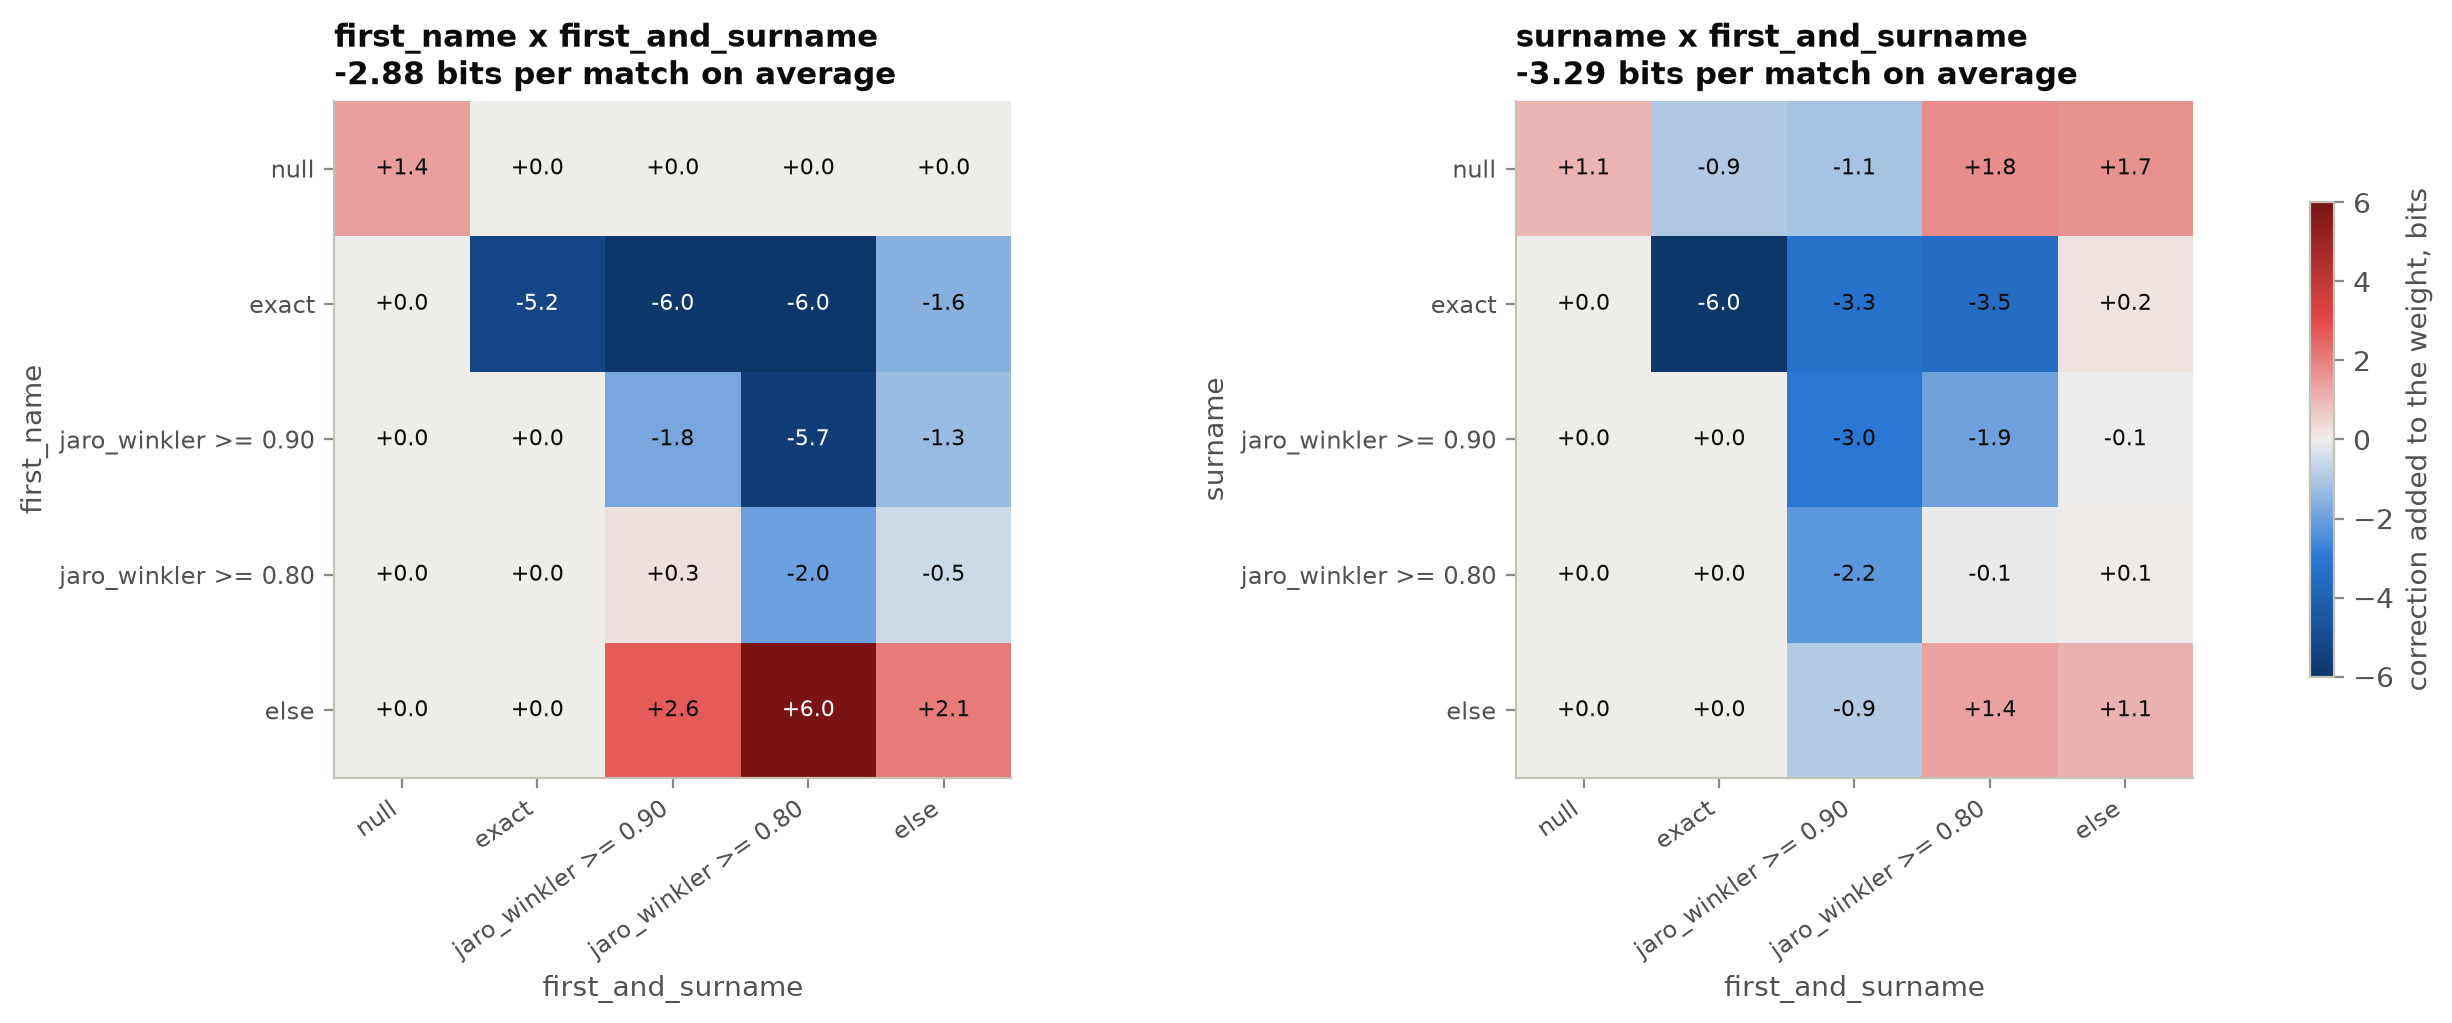

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, term in zip(axes, model_x.interactions):
    left = next(c for c in model_x.comparisons if c.name == term.left)
    right = next(c for c in model_x.comparisons if c.name == term.right)
    table = np.array(term.table).reshape(term.left_levels, term.right_levels)
    im = ax.imshow(table, cmap=DIVERGING, vmin=-6, vmax=6)
    ax.set_xticks(range(term.right_levels), [l.label for l in right.levels], rotation=35, ha="right", fontsize=8.5)
    ax.set_yticks(range(term.left_levels), [l.label for l in left.levels], fontsize=8.5)
    ax.set_xlabel(term.right)
    ax.set_ylabel(term.left)
    ax.grid(False)
    for i in range(term.left_levels):
        for j in range(term.right_levels):
            ax.text(j, i, f"{round(table[i, j], 1) + 0.0:+.1f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(table[i, j]) > 3.5 else INK)
    ax.set_title(f"{term.left} x {term.right}\n{term.match_bits:+.2f} bits per match on average")
_ = plt.colorbar(im, ax=axes, shrink=0.7, label="correction added to the weight, bits")

Two exact names and an exact full name were being counted three times; the (exact, exact) cell takes back 5.2 bits.
A first name that agrees exactly while the full name only fuzzily agrees is *more* evidence than the product said, +2.6.
Both models are scored below and the difference measured, because each term takes two to three bits off every match, so the operating threshold moves and a fixed one compares nothing.

## 8. Predict: score every candidate pair

`predict` walks the blocked union once, one thread per core, and writes every pair whose weight clears the threshold.
Three prunes keep the metrics off most pairs and are all exact: a per-value signature bounds a string metric before a character is read, the *ceiling* grants every comparison the best level the cheap bounds still admit and drops the pair when even that sum is under the threshold, and a per-pattern bracket on the term-frequency adjustment settles most patterns without a table lookup.
The threshold is 0 bits here, the posterior at even odds, so the whole frontier can be read off one file.

In [21]:
t = time.time()
predict = linker.predict(model, WORK / "predictions.parquet", threshold=0)
timings["predict"] = time.time() - t
predict_x = linker.predict(model_x, WORK / "predictions_interactions.parquet", threshold=0)
print(predict)

Threshold      0.000 bits  (posterior 0.500000)
Threads        8
Candidates     18,436,900
Predictions    376,921  (2.04% of candidates)
Elapsed        2.3 s  (8085301 candidates/s)

Zone           Candidate pairs       Share        Patterns
----------------------------------------------------------
skipped              1,645,268       8.92%               -
drop                 2,439,774      13.23%          11,063
check               14,088,403      76.41%          29,225
emit                   263,455       1.43%          49,712
----------------------------------------------------------
Comparisons avoided    1,645,268 (8.92% of candidates)
Term-frequency lookups 14,351,858, avoided 2,439,774 (13.23%).
The ceiling and the bracket are both admissible, so skipping and
dropping on them emit exactly the predictions scoring every pair would
have.

Predictions
  work/predictions.parquet
  8 shards merged and removed in 0.12 s



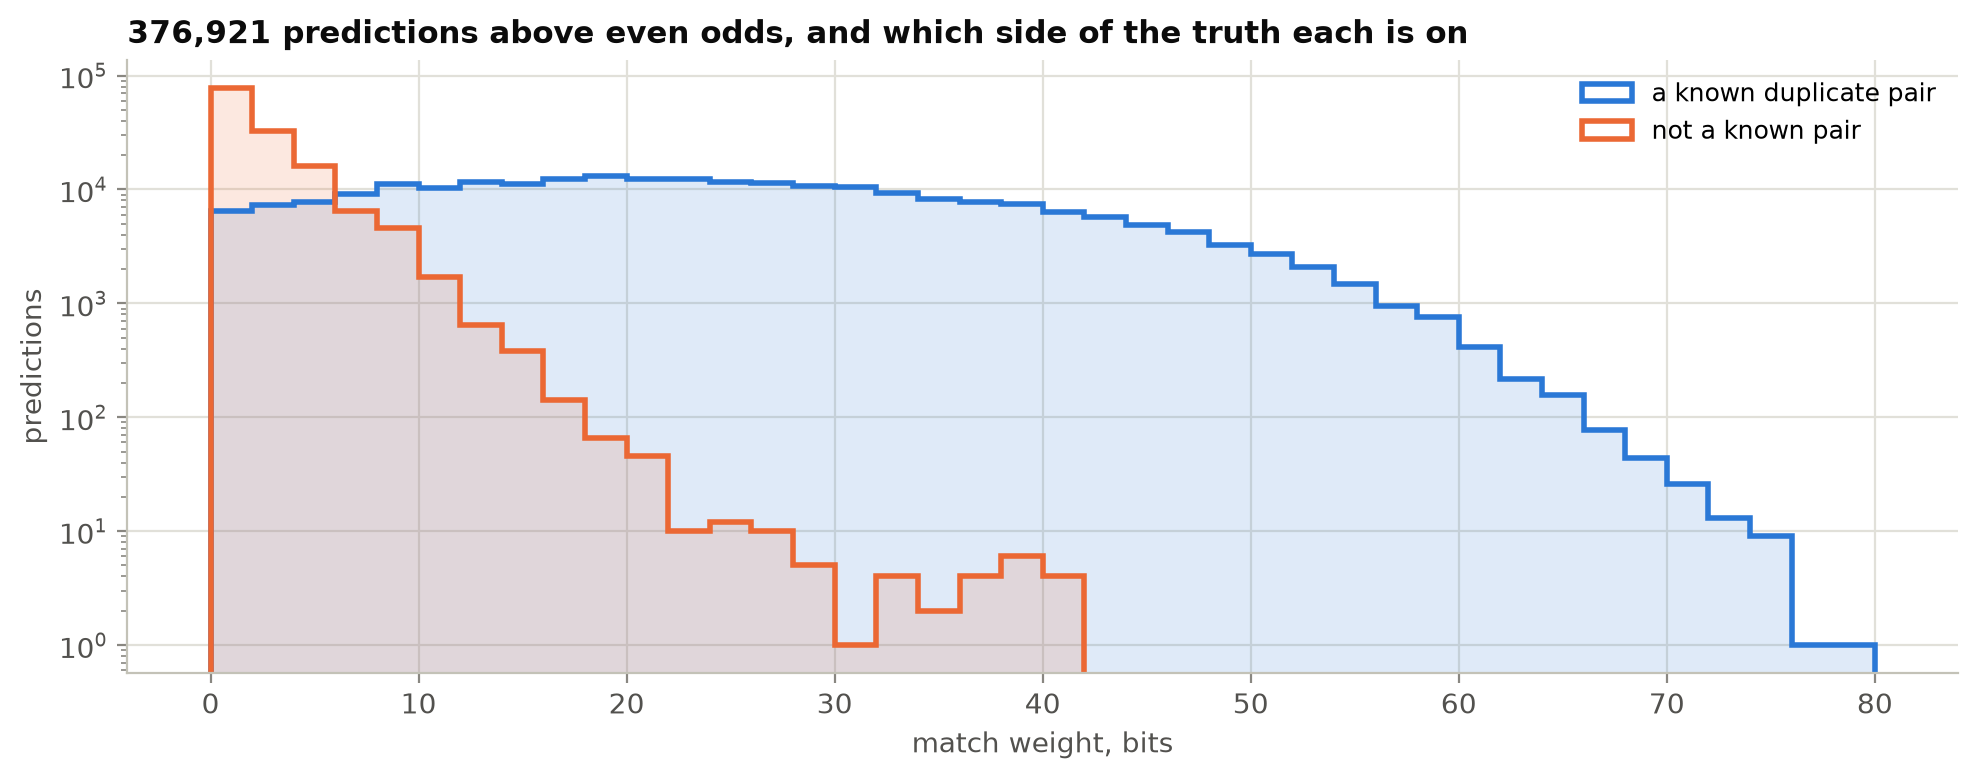

In [22]:
def read_predictions(path):
    df = pq.read_table(path).to_pandas()
    key = np.where(df.id_a < df.id_b, df.id_a + "|" + df.id_b, df.id_b + "|" + df.id_a)
    df["match"] = pd.Series(key).isin({f"{a}|{b}" for a, b in truth_pairs}).values
    return df

preds = read_predictions(WORK / "predictions.parquet")
preds_x = read_predictions(WORK / "predictions_interactions.parquet")

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(0, 82, 2)
for mask, color, label in [(preds.match, BLUE, "a known duplicate pair"), (~preds.match, ORANGE, "not a known pair")]:
    ax.hist(preds.match_weight[mask], bins=bins, color=color, histtype="stepfilled", alpha=0.15)
    ax.hist(preds.match_weight[mask], bins=bins, color=color, histtype="step", linewidth=2, label=label)
ax.set_yscale("log")
ax.set_xlabel("match weight, bits")
ax.set_ylabel("predictions")
ax.set_title(f"{len(preds):,} predictions above even odds, and which side of the truth each is on")
ax.legend()
plt.tight_layout()

The two populations are far apart, with the non-matches piled just above zero and the matches spread from 10 bits to 78.
Where they overlap, between 5 and 20 bits, is where the threshold is chosen, and the cluster sweep below is how.

## 9. Explain one score

A weight is a ledger: the prior, then each comparison's $\log_2(m/u)$ and its term-frequency move, then the interactions, with a running total that must end at the number in the predictions file.
`explain` prints it, and here it is drawn.
The first pair is two rows of the Thomas Clifford cluster above; the second is a pair that sits on the fence.

Pair  Q3129616-1  /  Q3129616-10

Comparison        Level                     Index   Values
----------------------------------------------------------------------------------------------------
first_name        jaro_winkler >= 0.80          3   helen  |  ellen
surname           exact                         1   jackson  |  jackson
first_and_surname jaro_winkler >= 0.90          2   helen jackson  |  ellen jackson
dob               null                          0   1850-01-01  |  <null>
postcode_fake     null                          0   ne46 1by  |  <null>
birth_place       else                          3   hexham  |  northumberland
occupation        null                          0   tennis player  |  <null>
gender            exact                         1   female  |  female




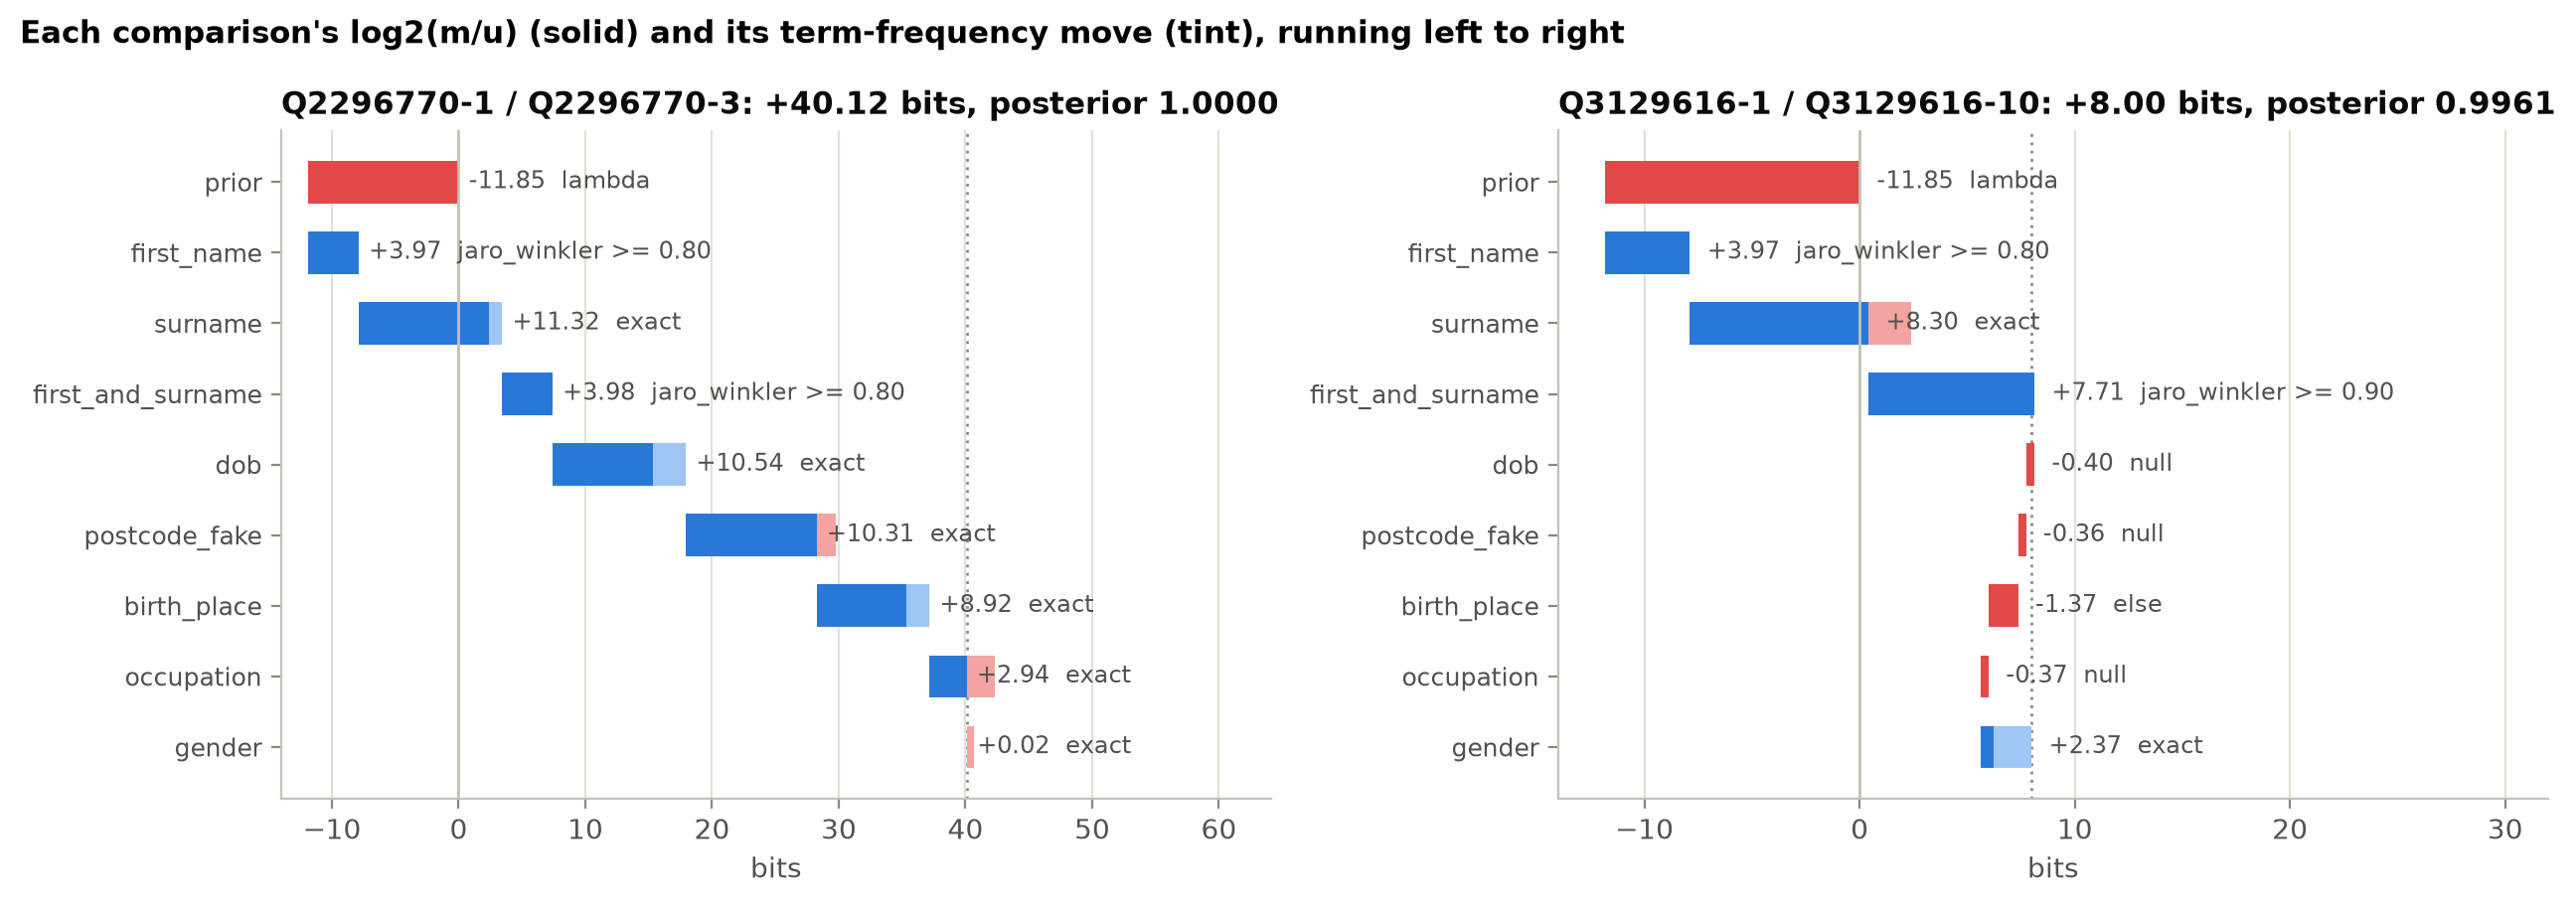

In [23]:
def draw_waterfall(ax, wf, title):
    steps = [("prior", wf.prior, 0.0, "lambda")]
    steps += [(s.name, s.bits, s.tf, s.label) for s in wf.steps]
    steps += [(f"{i.left} x {i.right}", i.bits, 0.0, "interaction") for i in wf.interactions]
    running = 0.0
    y = np.arange(len(steps))[::-1]
    for yi, (name, bits, tf, label) in zip(y, steps):
        ax.barh(yi, bits, left=running, height=0.6, color=BLUE if bits >= 0 else RED)
        ax.barh(yi, tf, left=running + bits, height=0.6, color="#9ec5f4" if tf >= 0 else "#f3a3a2")
        running += bits + tf
        ax.text(max(running, running - bits - tf) + 0.8, yi, f"{bits + tf:+.2f}  {label}",
                va="center", fontsize=8.5, color=INK2)
    ax.axvline(running, color=MUTED, linewidth=1, linestyle=(0, (1, 2)), zorder=0)
    ax.set_yticks(y, [s[0] for s in steps], fontsize=9)
    ax.grid(axis="y", visible=False)
    ax.axvline(0, color="#c3c2b7", linewidth=1)
    ax.set_xlabel("bits")
    ax.set_title(f"{title}: {wf.weight:+.2f} bits, posterior {wf.probability:.4f}")
    ax.set_xlim(min(-14, running - 2), max(30, running + 24))


clean = linker.explain("Q2296770-1", "Q2296770-3", model=model)
fence_row = preds.iloc[(preds.match_weight - 8).abs().argsort().iloc[0]]
fence = linker.explain(fence_row.id_a, fence_row.id_b, model=model)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
draw_waterfall(axes[0], clean.waterfall, f"{clean.id_a} / {clean.id_b}")
draw_waterfall(axes[1], fence.waterfall, f"{fence.id_a} / {fence.id_b}")
fig.suptitle("Each comparison's log2(m/u) (solid) and its term-frequency move (tint), running left to right",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()

print(fence.text[fence.text.index("Pair"):fence.text.index("gamma")])

The term-frequency move is what makes `thomas` worth less than `chudleigh`: an exact agreement on a name 1,448 rows share is worth 1.2 bits less than the level's average, an agreement on one 14 rows share 1.1 bits more.
On the second pair, the two names agree but everything else is missing or disagrees, and the weight lands near the fence.

## 10. Cluster: join the predictions into people

`cluster` streams the predictions past a union-find and keeps no edge.
The weight is in the file, so re-clustering at another threshold costs nothing, and with the truth file the partition is scored over its transitive closure: a chain a-b-c asserts a-c whether or not it was scored, which is a stricter number than a precision over edges.
Sweeping the threshold on both models gives the whole frontier.

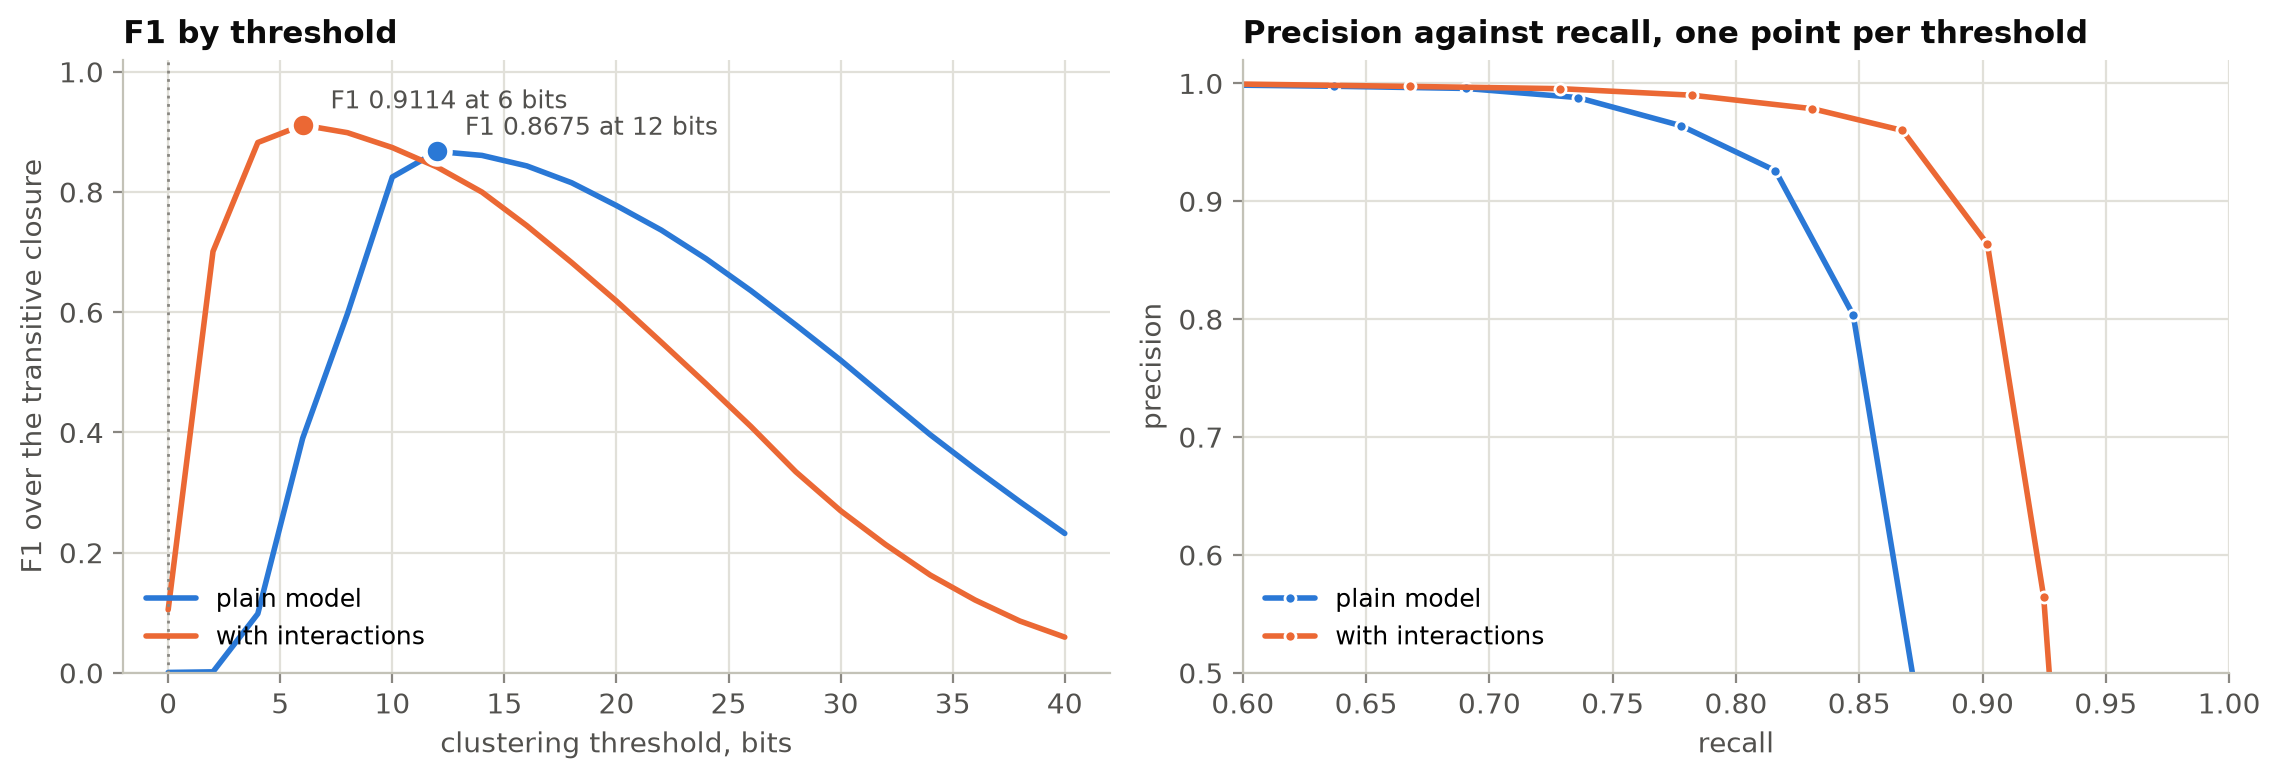

In [24]:
def sweep(path, thresholds):
    rows = []
    for th in thresholds:
        q = linker.cluster(path, threshold=th, truth=truth_path).quality
        rows.append({"threshold": th, "precision": q.precision, "recall": q.recall, "f1": q.f1})
    return pd.DataFrame(rows)

t = time.time()
thresholds = np.arange(0, 41, 2)
curve = sweep(WORK / "predictions.parquet", thresholds)
curve_x = sweep(WORK / "predictions_interactions.parquet", thresholds)
timings["cluster sweep, 2 x 21 thresholds"] = time.time() - t
best = curve.loc[curve.f1.idxmax()]
best_x = curve_x.loc[curve_x.f1.idxmax()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
for name, c, color in [("plain model", curve, BLUE), ("with interactions", curve_x, ORANGE)]:
    ax1.plot(c.threshold, c.f1, color=color, label=name)
    ax2.plot(c.recall, c.precision, color=color, marker="o", markersize=4, markeredgecolor="white", label=name)
for b, color in [(best, BLUE), (best_x, ORANGE)]:
    ax1.plot(b.threshold, b.f1, "o", color=color, markersize=9, markeredgecolor="white", markeredgewidth=2)
    ax1.annotate(f"F1 {b.f1:.4f} at {b.threshold:.0f} bits", (b.threshold, b.f1), (10, 6),
                 textcoords="offset points", fontsize=9, color=INK2)
ax1.axvline(0, color=MUTED, linewidth=1, linestyle=(0, (1, 2)))
ax1.set_xlabel("clustering threshold, bits")
ax1.set_ylabel("F1 over the transitive closure")
ax1.set_ylim(0, 1.02)
ax1.set_title("F1 by threshold")
ax1.legend(loc="lower left")
ax2.set_xlabel("recall")
ax2.set_ylabel("precision")
ax2.set_xlim(0.6, 1)
ax2.set_ylim(0.5, 1.02)
ax2.set_title("Precision against recall, one point per threshold")
ax2.legend(loc="lower left")
plt.tight_layout()

Blocking reached 85% of the true pairs and the closure recovers some of the rest, since a pair never compared is still asserted when its two records join one cluster through others, which is how recall runs above pair completeness at low thresholds.
The corrected model reaches more recall at every precision.
The operating point also moves, from 12 bits to 6, because each interaction term takes bits off every match; reading a fixed threshold would show the correction as a loss where the frontier shows +0.04 F1.

In [25]:
result = linker.cluster(WORK / "predictions_interactions.parquet", threshold=best_x.threshold,
                        truth=truth_path, out=WORK / "clusters.csv")
print(result)

Read 247,738 predictions from work/predictions_interactions.parquet in 0.090094 s
Resolved their ids against the record ids in 0.0108813 s
Kept 200,216 above the clustering threshold (80.82%)
Weights 6.00004 to 67.3141 bits
41,866 of them merged two components (20.91%)

5,247 clusters of two or more, covering 47,113 records (93.15%)
3,465 records stayed alone
Largest cluster 54 records; the partition asserts 274,646 duplicate pairs
47,113 rows written

Size            Clusters          Records
-------------------------------------------
1 (singleton)       3,465            3,465
2                     430              860
3                     682            2,046
4                     463            1,852
5                     394            1,970
6-10                1,354           10,589
11-100              1,924           29,796
-------------------------------------------

Against the known duplicates, with both sides closed transitively:
  listed     303,961 pairs in the truth file

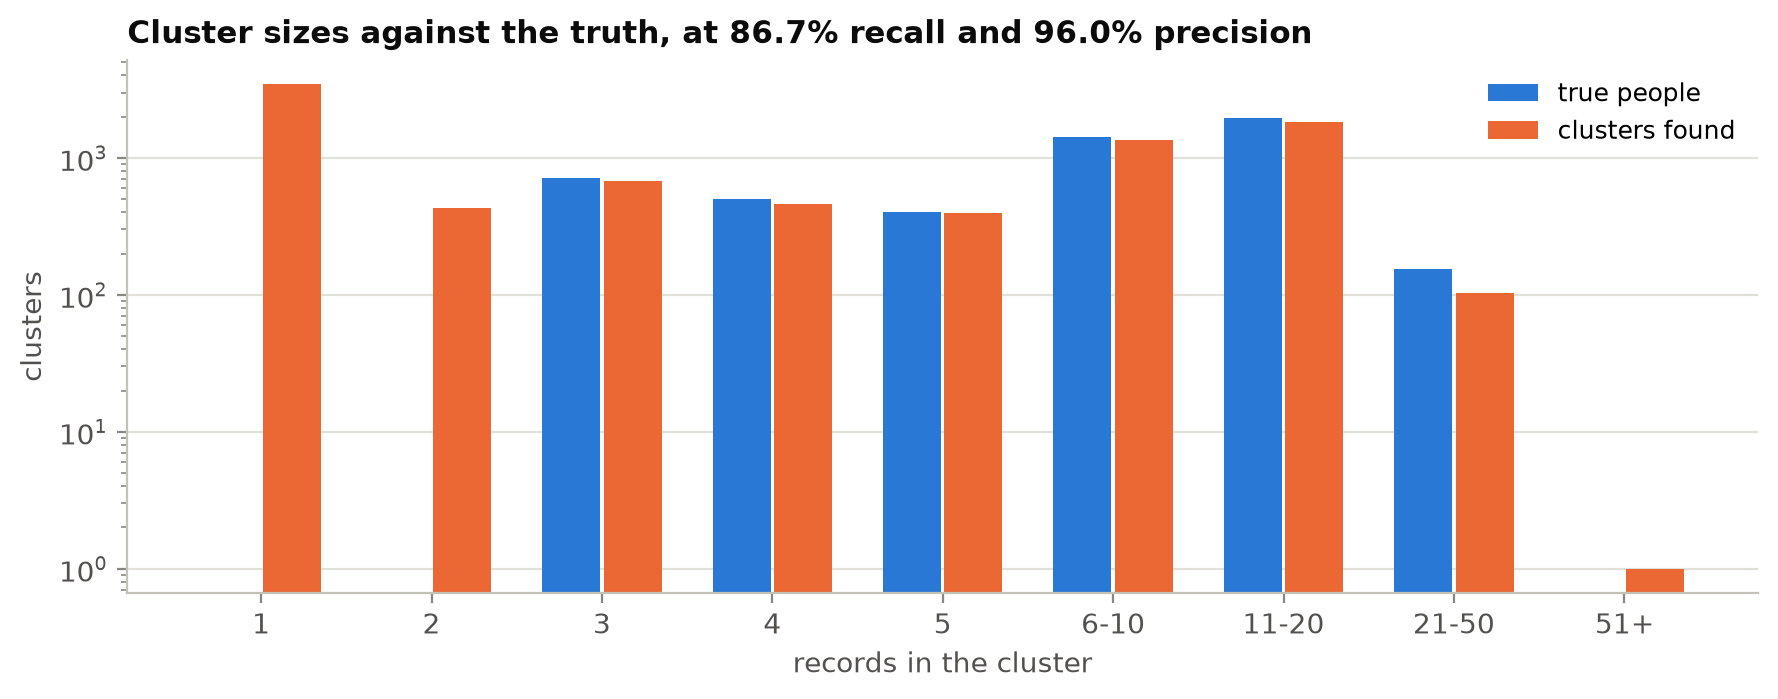

In [26]:
clusters = pd.read_csv(WORK / "clusters.csv")
found_sizes = clusters.groupby("cluster_id").size()
edges = [1, 2, 3, 4, 5, 6, 11, 21, 51, 1000]
labels = ["1", "2", "3", "4", "5", "6-10", "11-20", "21-50", "51+"]
singletons = result.report.singletons
dist = pd.DataFrame({
    "truth": pd.cut(sizes, edges, right=False, labels=labels).value_counts().sort_index(),
    "found": pd.cut(found_sizes, edges, right=False, labels=labels).value_counts().sort_index(),
})
dist.loc["1", "found"] = singletons

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(dist))
ax.bar(x - 0.18, dist["truth"], width=0.34, color=BLUE, label="true people")
ax.bar(x + 0.18, dist["found"], width=0.34, color=ORANGE, label="clusters found")
ax.set_xticks(x, dist.index)
ax.set_xlabel("records in the cluster")
ax.set_ylabel("clusters")
ax.set_yscale("log")
ax.grid(axis="x", visible=False)
ax.set_title(f"Cluster sizes against the truth, at {result.quality.recall:.1%} recall and {result.quality.precision:.1%} precision")
ax.legend()
plt.tight_layout()

The singletons and pairs are records whose duplicates blocking never reached or the model never scored high enough, and a person of 20 records split in two is what the missing recall looks like from the cluster side.
The one cluster above 50 records is the other kind of error, and the notebook can say so only because it has the labels.
Here is what the clusters hold, joined back to the source rows: first the person the notebook opened with, then the composition of that largest cluster.

In [27]:
merged = clusters.merge(raw, on="unique_id")
thomas = merged[merged.cluster_id == merged.loc[merged.unique_id == "Q2296770-1", "cluster_id"].item()]
print(f"the cluster holding Q2296770-1: {len(thomas)} records, {thomas['cluster'].nunique()} true person, "
      f"{(raw['cluster'] == 'Q2296770').sum()} records in the truth")
display(thomas[["unique_id", "first_name", "surname", "dob", "birth_place", "postcode_fake", "occupation"]])

biggest = merged[merged.cluster_id == found_sizes.idxmax()]
print(f"the largest cluster: {len(biggest)} records over {biggest['cluster'].nunique()} true people")
biggest.groupby("cluster").agg(records=("unique_id", "size"), first_name=("first_name", "first"),
                               surname=("surname", "first"), dob=("dob", "first"), birth_place=("birth_place", "first"))

the cluster holding Q2296770-1: 16 records, 1 true person, 16 records in the truth


,unique_id,first_name,surname,dob,birth_place,postcode_fake,occupation
0,Q2296770-1,thomas,chudleigh,1630-08-01,devon,tq13 8df,politician
1,Q2296770-2,thomas,chudleigh,1630-08-01,devon,tq13 8df,politician
2,Q2296770-3,tom,chudleigh,1630-08-01,devon,tq13 8df,politician
3,Q2296770-4,thomas,chudleigh,1630-08-01,devon,tq13 8hu,politician
4,Q2296770-5,thomas,chudleigh,1630-08-01,devon,tq13 8df,politician
5,Q2296770-6,thomas,chudleigh,1630-08-01,west devon,tq13 8df,politician
6,Q2296770-7,tom,chudleigh,1630-08-01,west devon,tq13 8df,NaN
7,Q2296770-8,tom,chudleigh,NaN,devon,tq13 8df,politician
8,Q2296770-9,thomas,chudleigh,1630-05-01,NaN,NaN,politician
9,Q2296770-10,thomas,chudleigh,NaN,devon,tq13 8jr,politician


the largest cluster: 54 records over 3 true people


,records,first_name,surname,dob,birth_place
cluster,,,,,
Q15070090,16,george,pelham,1766-01-01,newcastle upon tyne
Q28054162,18,sidney,pelham,1849-05-16,sheffield
Q6252444,20,john,pelham,1811-06-21,sheffield


## 11. Blocking recall with no truth file

On a real job there is no `truth.csv`.
`completeness` estimates pair completeness from the model and the term frequencies alone: an exact-value source fires exactly when $\gamma$ says the column agrees, a rare-value cap is answered by the term-frequency table, and what remains is the mass of matches on the *dark* patterns no source produces.
Taking $m(\gamma)$ as the product of the learned parameters overstates it, because agreement is correlated among matches; the estimate instead fits a capture table over the observed cells, with independence and two-way interactions both tried and BIC choosing.

In [28]:
t = time.time()
completeness = linker.completeness(model, truth=truth_path)
timings["completeness"] = time.time() - t

pc = pd.DataFrame({
    "estimator": ["product of the learned m, best source per pattern", "product, with the correction",
                  "capture table, independent dark cells", "capture table, two-way interactions",
                  "chosen by BIC", "measured against the 303,961 known pairs"],
    "pair completeness": [completeness.pc_product, completeness.pc_analytic, completeness.pc_independence,
                          completeness.pc_interaction, completeness.pc_estimate, completeness.pc_measured],
})
pc["pair completeness"] /= 100
print(f"{completeness.cells:,} cells, {completeness.dark_cells:,} dark; "
      f"BIC {completeness.bic_independence:,.0f} independent against {completeness.bic_interaction:,.0f} with interactions")
fmt(pc, **{"pair completeness": "{:.2%}"})

2,500 cells, 768 dark; BIC 1,508,994 independent against 54,302 with interactions


estimator,pair completeness
"product of the learned m, best source per pattern",0.97%
"product, with the correction",0.97%
"capture table, independent dark cells",0.95%
"capture table, two-way interactions",0.86%
chosen by BIC,0.86%
"measured against the 303,961 known pairs",0.85%


The product model reads 96.6% where the truth is 85.0%, which is what conditional dependence between the blocked columns looks like; the capture table reads 86.1%, one point off, and needed no known pair.

## 12. Simplify: which levels earn their bits?

Two adjacent levels differ only in $\log_2(m/u)$, so a run's pairs split by class make a 2x2 table per adjacent pair and a likelihood-ratio test asks whether the two weights are distinguishable.
Over 18 million pairs everything is distinguishable, so the test's power is the size of the run and the number to decide on is the gap in bits: `min_gap=1.0` merges a level within a bit of its neighbour.

In [29]:
t = time.time()
simplify, simplified = linker.simplify(model, min_gap=1.0)
timings["simplify"] = time.time() - t

tests = []
for c in simplify.comparisons:
    for test in c.tests:
        if test.expressible:
            tests.append({"comparison": c.name, "levels": f"{c.levels[test.upper].label} / {c.levels[test.lower].label}",
                          "gap, bits": test.gap, "G2": test.g2, "verdict": "merged" if test.merged else "kept"})
print(f"gamma {simplify.width} -> {simplify.proposed_width} bits, {simplify.merged_levels} levels merged")
fmt(pd.DataFrame(tests).sort_values("gap, bits"), G2="{:,.0f}", **{"gap, bits": "{:.2f}"})

gamma 20 -> 18 bits, 2 levels merged


comparison,levels,"gap, bits",G2,verdict
first_name,jaro_winkler >= 0.90 / jaro_winkler >= 0.80,0.54,"2,529",merged
dob,levenshtein <= 2 / else,0.71,"3,224",merged
first_name,exact / jaro_winkler >= 0.80,1.36,"44,494",kept
postcode_fake,exact / levenshtein <= 1,2.05,933,kept
gender,exact / else,2.56,"131,816",kept
surname,exact / jaro_winkler >= 0.90,2.57,"11,326",kept
birth_place,exact / jaro_winkler >= 0.90,2.66,"5,093",kept
first_and_surname,exact / jaro_winkler >= 0.90,3.26,"22,199",kept
first_and_surname,jaro_winkler >= 0.90 / jaro_winkler >= 0.80,3.74,"138,504",kept
dob,exact / levenshtein <= 1,3.98,"170,346",kept


`first_name`'s two Jaro-Winkler levels are 0.54 bits apart and `dob`'s `levenshtein <= 2` is 0.72 bits from `else`, which is no evidence at all.
Merging them takes $\gamma$ from 20 to 18 bits and the tabulated pattern space from 90,000 to 57,600; the project measured F1 moving by at most 0.0007 at any threshold.
`simplified` is the rewritten `Schema`, which wants `estimate` run again because $\gamma$ packs differently.

## 13. Rescore without comparing again

$\gamma$ is everything the comparison produced, so a run that spills `(a, b, γ)` at 12 bytes a pair can be replayed under another model without touching a string.
Raising the threshold on a spill is exact, and replaying under a different model is exact for every pair the spill holds; what it cannot hold is a pair the model that wrote it dropped, which is what the second line below shows.

In [30]:
spill = WORK / "spill"
t = time.time()
linker.predict(model, WORK / "predictions_spilled.parquet", threshold=0, spill=spill)
spilled = time.time() - t

t = time.time()
linker.rescore(model, spill, WORK / "rescored.parquet", threshold=best.threshold)
timings["rescore"] = time.time() - t
replayed = pq.read_table(WORK / "rescored.parquet").to_pandas().sort_values(["id_a", "id_b"]).reset_index(drop=True)
direct = preds[preds.match_weight >= best.threshold].sort_values(["id_a", "id_b"]).reset_index(drop=True)
same = replayed[["id_a", "id_b", "match_weight"]].equals(direct[["id_a", "id_b", "match_weight"]])
print(f"predict with a spill: {spilled:.2f} s; rescore at {best.threshold:.0f} bits: {timings['rescore']:.3f} s, "
      f"{len(replayed):,} predictions, {'identical to' if same else 'DIFFERENT from'} scoring the pairs directly")

linker.rescore(model_x, spill, WORK / "rescored_interactions.parquet", threshold=best_x.threshold)
again = pq.read_table(WORK / "rescored_interactions.parquet").num_rows
direct_x = int((preds_x.match_weight >= best_x.threshold).sum())
print(f"under the interaction model: {again:,} replayed against {direct_x:,} scored directly, "
      f"{direct_x - again} pairs the plain model kept below 0 bits and the correction lifts above {best_x.threshold:.0f}")

predict with a spill: 2.45 s; rescore at 12 bits: 0.099 s, 184,725 predictions, identical to scoring the pairs directly
under the interaction model: 200,186 replayed against 200,216 scored directly, 30 pairs the plain model kept below 0 bits and the correction lifts above 6


## 14. What it cost, and what it found

Every stage over 50,578 records and 18.4 million candidate pairs, on this machine:

In [31]:
timing = pd.DataFrame({"stage": list(timings), "seconds": list(timings.values())})
summary = pd.DataFrame({
    "quantity": ["records", "people", "candidate pairs", "of the pair space", "pair completeness, blocking",
                 "pair completeness, estimated blind", "predictions above even odds",
                 "best F1, plain model", "best F1, with interactions", "precision at that point", "recall at that point"],
    "value": [f"{linker.records:,}", f"{len(sizes):,}", f"{m.candidate_union:,}",
              f"{m.candidate_union / m.pair_space:.2%}", f"{m.pair_completeness:.2%}",
              f"{completeness.pc_estimate:.2f}%", f"{len(preds):,}",
              f"{best.f1:.4f} at {best.threshold:.0f} bits", f"{best_x.f1:.4f} at {best_x.threshold:.0f} bits",
              f"{best_x.precision:.4f}", f"{best_x.recall:.4f}"],
})
display(fmt(summary))
fmt(timing, seconds="{:.2f}")

quantity,value
records,"50,578"
people,"5,156"
candidate pairs,0
of the pair space,0.00%
"pair completeness, blocking",84.99%
"pair completeness, estimated blind",0.86%
predictions above even odds,"376,921"
"best F1, plain model",0.8675 at 12 bits
"best F1, with interactions",0.9114 at 6 bits
precision at that point,0.9601


stage,seconds
load,0.03
profile,0.07
blocking + recall,0.61
levels,5.92
estimate,1.17
"estimate, interactions",1.13
predict,2.29
"cluster sweep, 2 x 21 thresholds",8.87
completeness,2.31
simplify,1.37


The whole pipeline, profile to clusters, runs in under a minute on a laptop, and nothing in it held a row per pair.
The same code is what ran the 20 million record target: 10 billion candidate pairs in 38 minutes on one thread at 4.5 GB resident, which is the number the design exists for.

Where to go from here:

- `print(profile)`, `print(estimate)`, `print(recall)` and the rest print the full reports the command line prints, and `estimate.full_text` holds every residual pair of every session.
- `linker.explain(a, b, model=model)` is the ledger for any pair, and `python -m cpplink explain --predictions predictions.parquet --out waterfalls.parquet` writes every prediction's ledger as one wide row.
- `cpplink.Linker(schema, [file_a, file_b])` links two files instead of deduplicating one, and scores only the pairs that cross them.
- `docs/` covers the model, the blocking, the dependence diagnostics and the Python API in full.